#  **Numerical weather prediction using neural networks**

## **Imports**

In [ ]:
import os
import time
import random
import string

from typing import List

import numpy as np

import pandas as pd

from pandas.tseries import offsets
from pandas.tseries.frequencies import to_offset


import matplotlib.pyplot as plt
import librosa
import seaborn as sns
from scipy.signal import detrend

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler


import math



import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

#from cupyx.scipy.special import erfinv as cupy_erfinv
#import cupy as cp
#import cudf as gd
from scipy.special import erfinv
from scipy.stats import norm




from math import sqrt



## Random Seed generation for reproducability

In [ ]:
SEED = 42




random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

torch.backends.cuda.matmul.allow_tf32 = False
torch.backends.cudnn.allow_tf32 = False

torch.use_deterministic_algorithms(True)


def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

## Loading the and splitting data set

In [ ]:
data_file=pd.read_excel("/content/drive/MyDrive/E.M.Y_project/Λάρισα_data(16648).xlsx")
data_file.drop(columns=['Unnamed: 0'], inplace=True)
data_file.drop(columns=['PRODUCTID'], inplace=True)


id_col = ["WMONO"]

time_cols = [
    "OBSERVATIONYEAR",
    "OBSERVATIONMONTH",
    "OBSERVATIONDAY",
    "OBSERVATIONHOUR"
]

target_cols = [
    "DRYTEMP", "MAXTEMP", "MINTEMP", "RELHUMIDITY",
    "PRECIPHEIGHT", "WETTEMP", "VISIBILITY",
    "WINDDIRECTION", "WINDFORCEKNOT", "DEWLINGPOINT",
    "HYDRTENDENCY"
]


min_year=data_file['OBSERVATIONYEAR'].min()

for col in target_cols:
    data_file[col] = data_file[col].astype(str).str.replace(',', '.').astype(float)

data_file = data_file.loc[:, ~data_file.columns.duplicated()]
data_file['VISIBILITY']=data_file['VISIBILITY'].clip(upper=10)
data_file['OBSERVATIONHOUR']=data_file['OBSERVATIONHOUR']// 3





train=data_file[data_file['OBSERVATIONYEAR']<=2016]
val=data_file[(data_file['OBSERVATIONYEAR']<=2019) & (data_file['OBSERVATIONYEAR']>=2017)]
test=data_file[(data_file['OBSERVATIONYEAR']==2020)]





## Exploratory Data analysis

### Initial print of the training set

In [ ]:
train

,WMONO,OBSERVATIONYEAR,OBSERVATIONMONTH,OBSERVATIONDAY,OBSERVATIONHOUR,DRYTEMP,MAXTEMP,MINTEMP,RELHUMIDITY,PRECIPHEIGHT,WETTEMP,VISIBILITY,WINDDIRECTION,WINDFORCEKNOT,DEWLINGPOINT,HYDRTENDENCY
0,16648,2000,1,1,0,1.8,NaN,NaN,82.0,NaN,0.8,10.0,200.0,5.0,-0.9,5.676922
1,16648,2000,1,1,1,1.0,NaN,NaN,86.0,NaN,0.2,10.0,300.0,7.0,-1.1,5.561577
2,16648,2000,1,1,2,2.0,4.4,0.4,76.0,NaN,0.6,10.0,240.0,7.0,-1.8,5.264429
3,16648,2000,1,1,3,3.4,NaN,NaN,80.0,NaN,2.2,10.0,0.0,0.0,0.2,6.201608
4,16648,2000,1,1,4,6.6,NaN,NaN,60.0,NaN,3.8,10.0,340.0,4.0,-0.7,5.783258
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49543,16648,2016,12,31,3,0.6,NaN,NaN,60.0,NaN,NaN,10.0,250.0,6.0,-6.2,NaN
49544,16648,2016,12,31,4,5.0,NaN,NaN,42.0,NaN,NaN,10.0,290.0,10.0,-7.0,NaN
49545,16648,2016,12,31,5,4.2,NaN,NaN,50.0,NaN,NaN,10.0,240.0,5.0,-5.2,NaN
49546,16648,2016,12,31,6,3.4,5.0,-3.8,49.0,NaN,NaN,10.0,320.0,4.0,-6.2,NaN


### Occurance of each value for the output labels

#### Arrays

In [ ]:
for col in target_cols:
    print(train[col].value_counts(), "\n\n")

DRYTEMP
 10.000000    520
 15.000000    479
 20.000000    469
 19.000000    453
 17.000000    449
             ... 
-9.200000       1
 21.299999      1
 15.700000      1
 13.300000      1
 29.700001      1
Name: count, Length: 444, dtype: int64 


MAXTEMP
11.0    125
28.0    114
30.0    108
20.0    107
27.0    105
       ... 
3.5       1
17.9      1
18.9      1
14.5      1
4.7       1
Name: count, Length: 538, dtype: int64 


MINTEMP
 18.0    139
 7.0     137
 19.0    127
 17.0    126
 15.0    124
        ... 
 25.1      1
-5.1       1
-6.1       1
-6.5       1
-1.7       1
Name: count, Length: 445, dtype: int64 


RELHUMIDITY
100.0    2339
97.0     1523
96.0      984
90.0      957
94.0      937
         ... 
11.0        6
10.0        4
7.0         3
9.0         3
5.0         1
Name: count, Length: 94, dtype: int64 


PRECIPHEIGHT
0.0     1156
0.1      544
0.2      390
0.3      293
0.5      221
        ... 
9.1        1
22.5       1
27.1       1
30.4       1
55.0       1
Name: count, L

#### Graphs

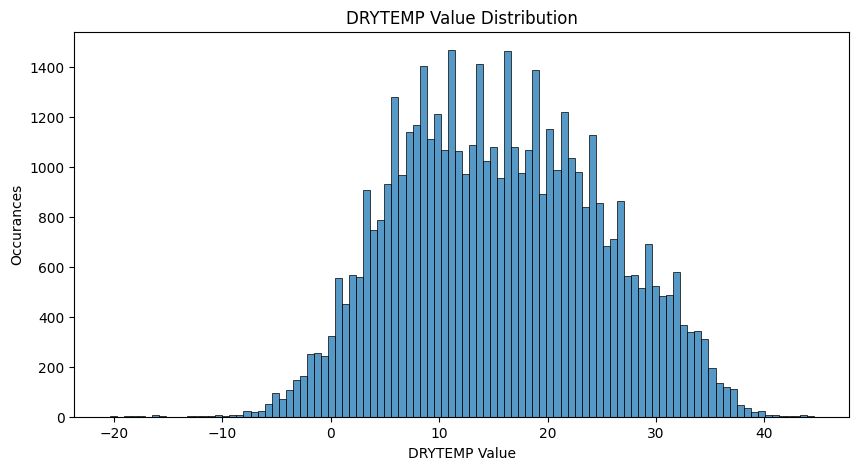

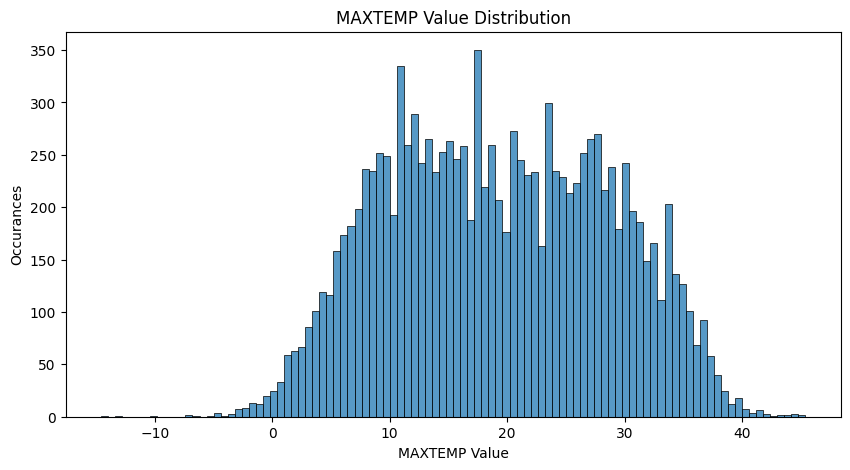

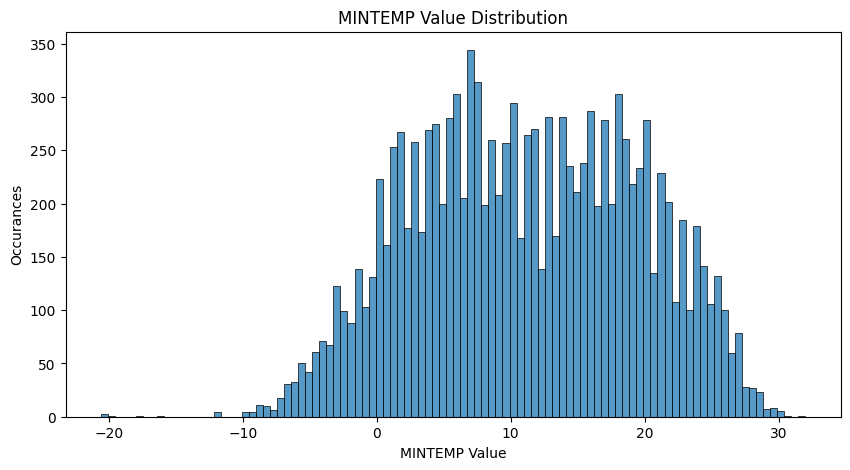

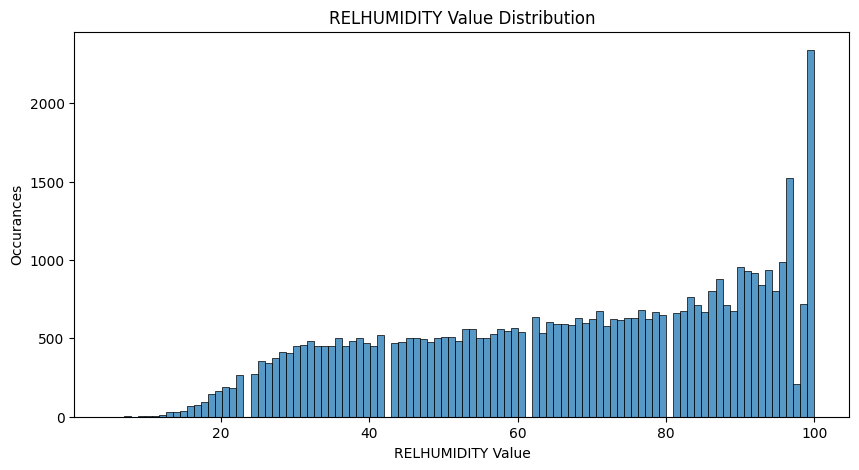

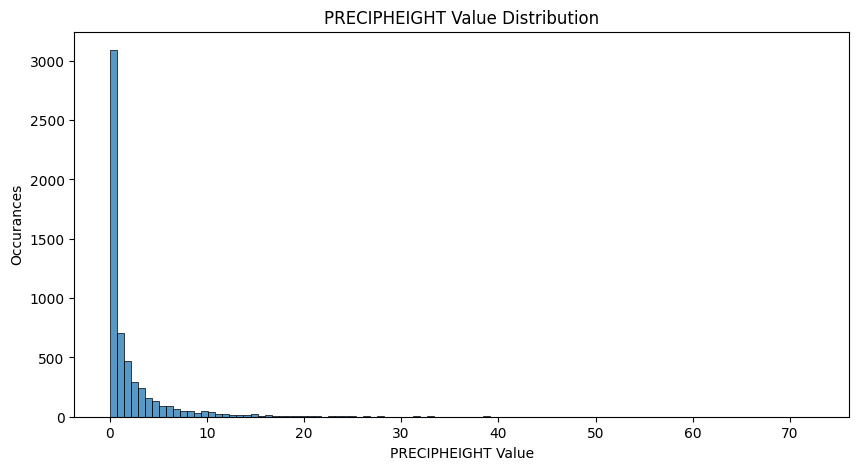

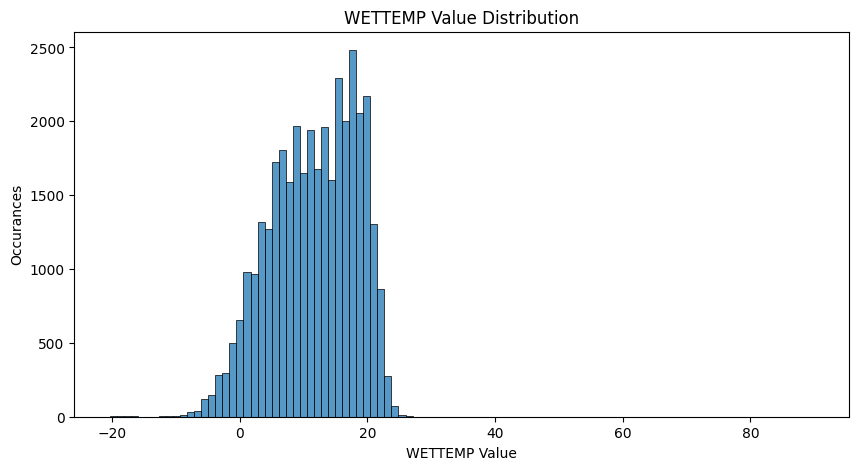

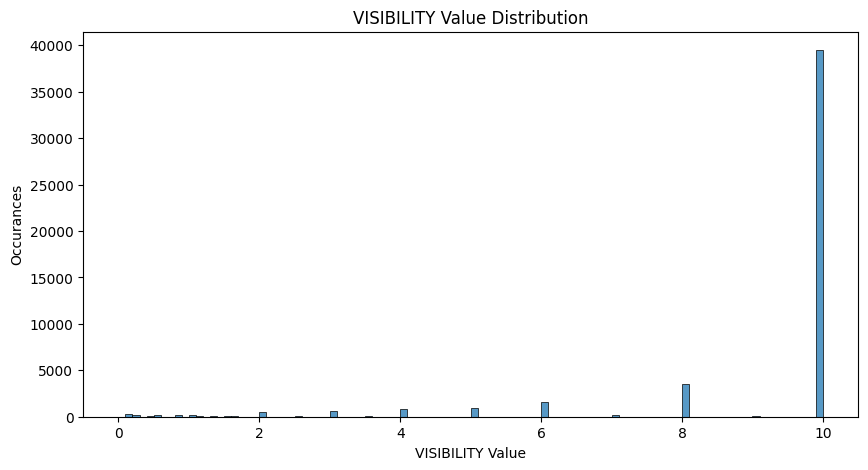

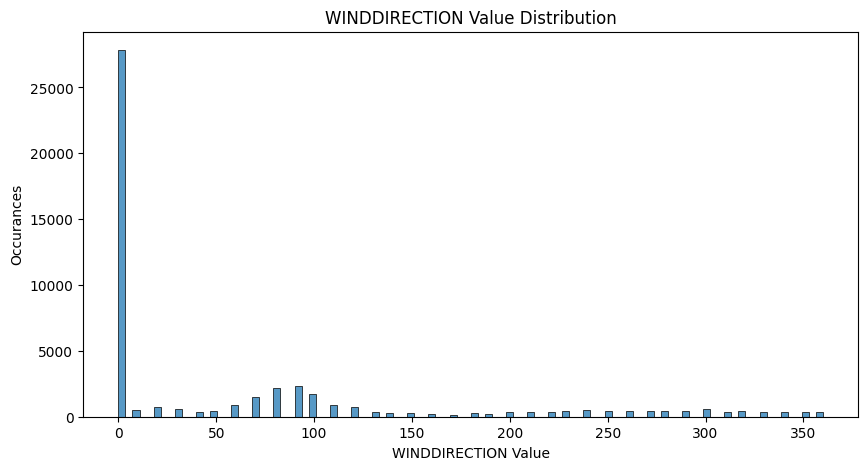

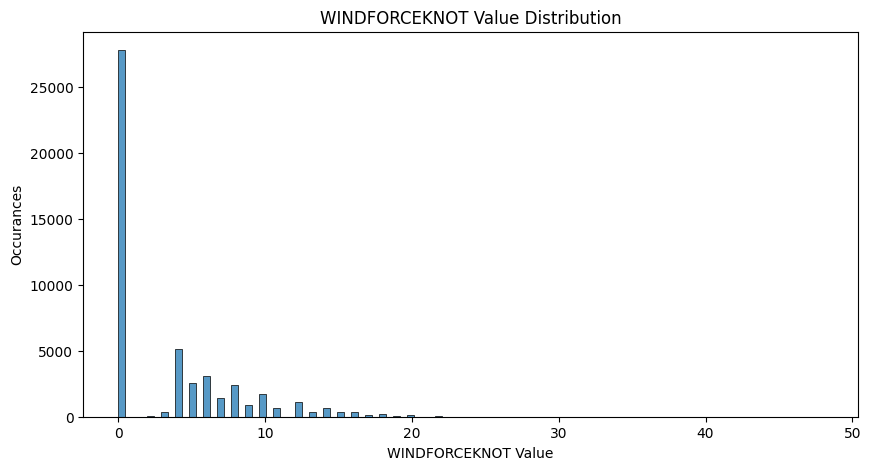

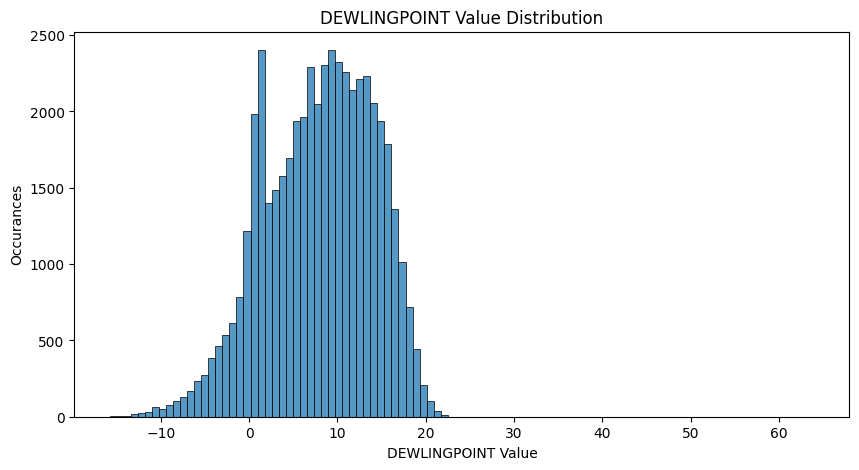

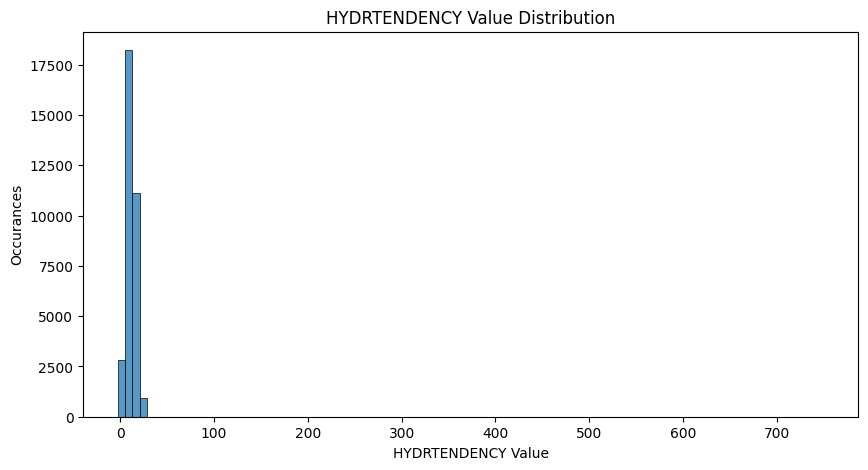

In [ ]:
for col in target_cols:
    plt.figure(figsize=(10,5))
    sns.histplot(train[col], bins=100)
    plt.title(f"{col} Value Distribution")
    plt.xlabel(f"{col} Value")
    plt.ylabel("Occurances")
    print("\n")

### Value progression over time  

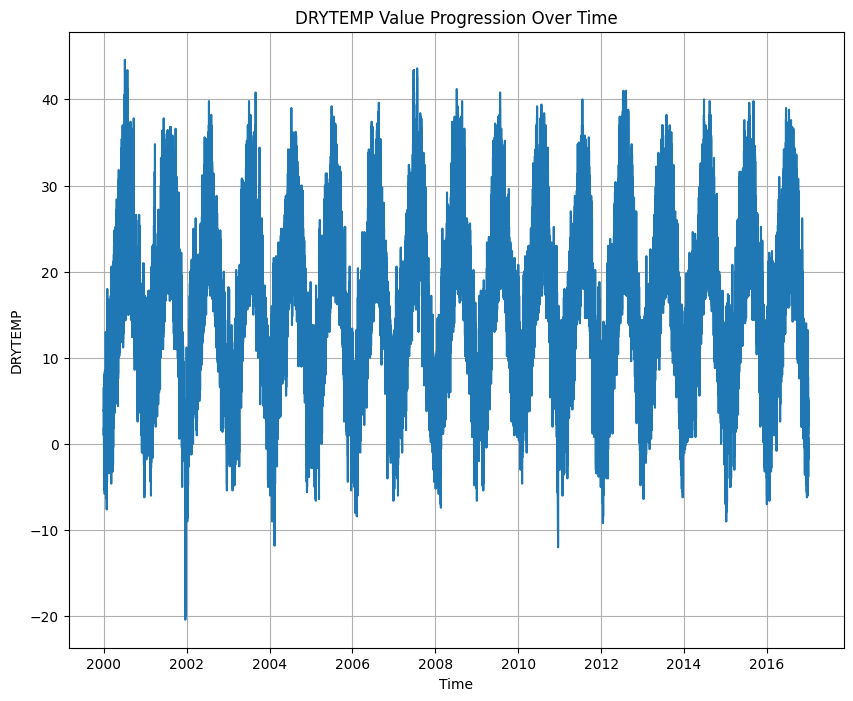

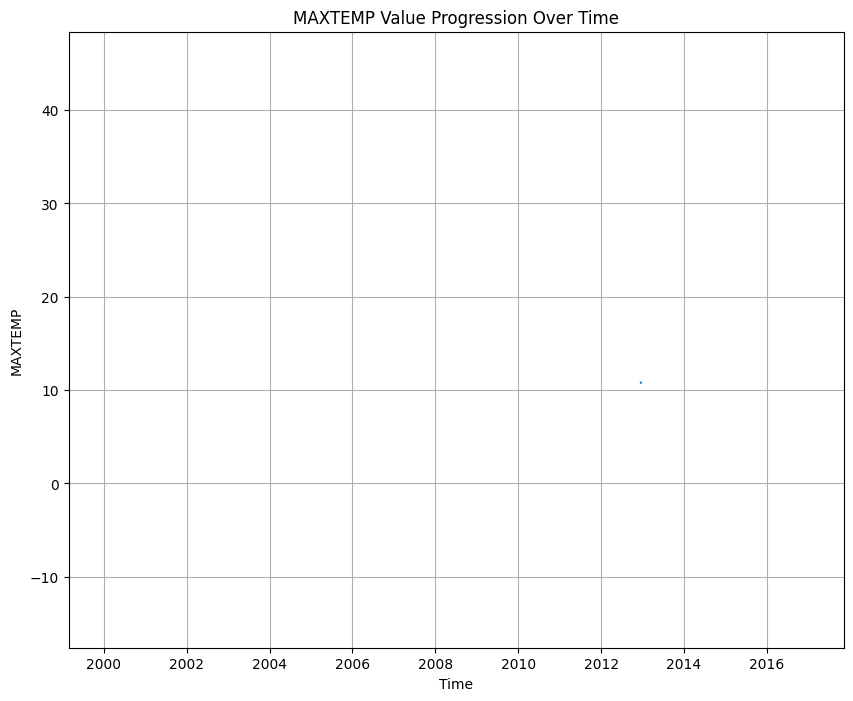

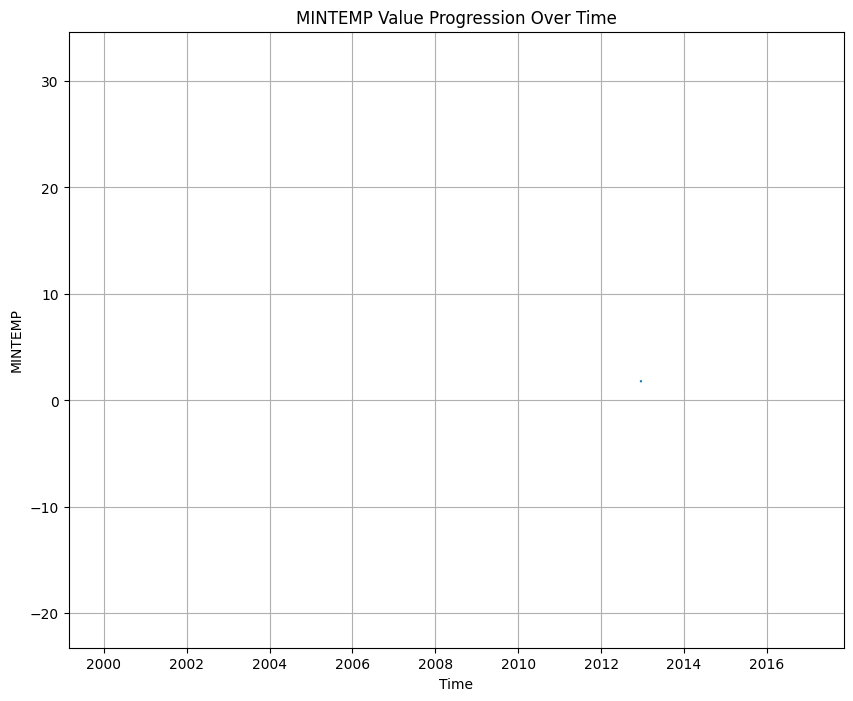

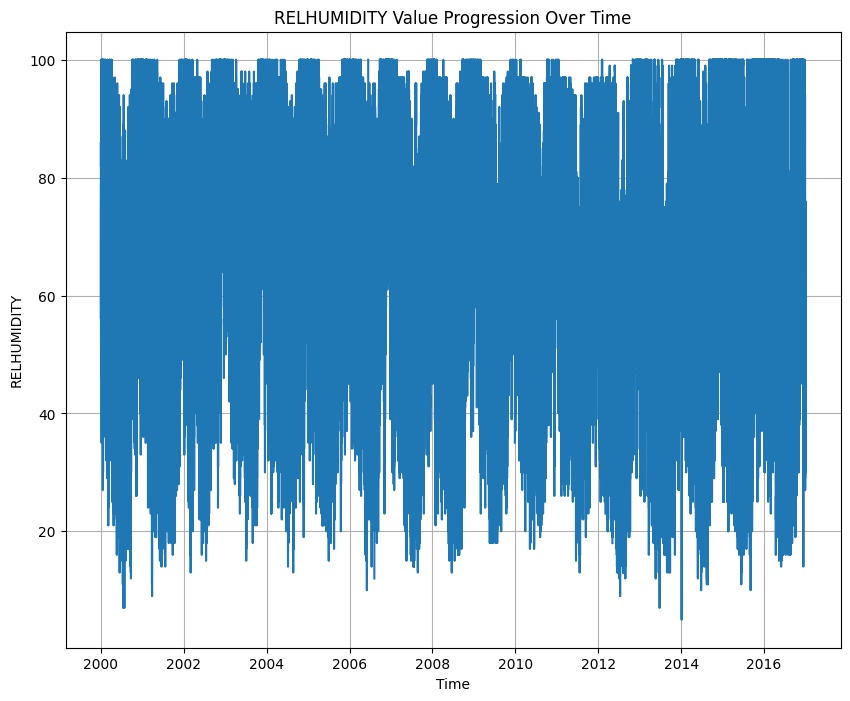

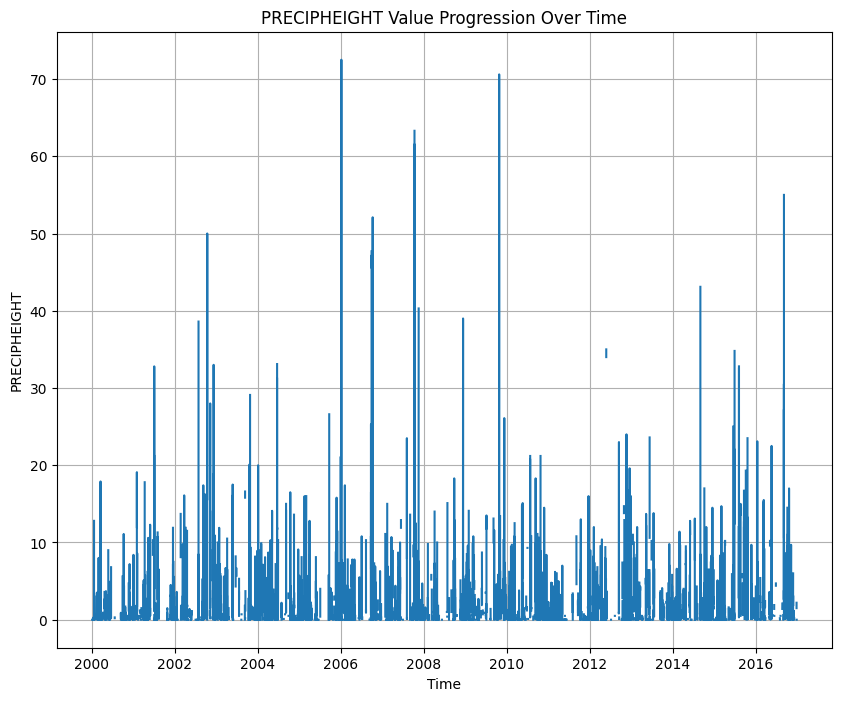

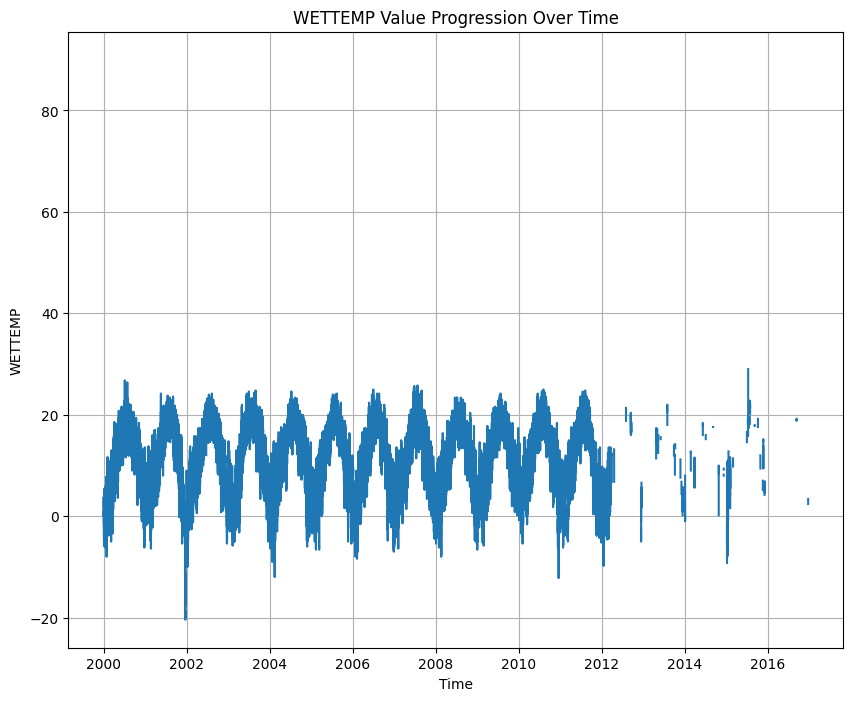

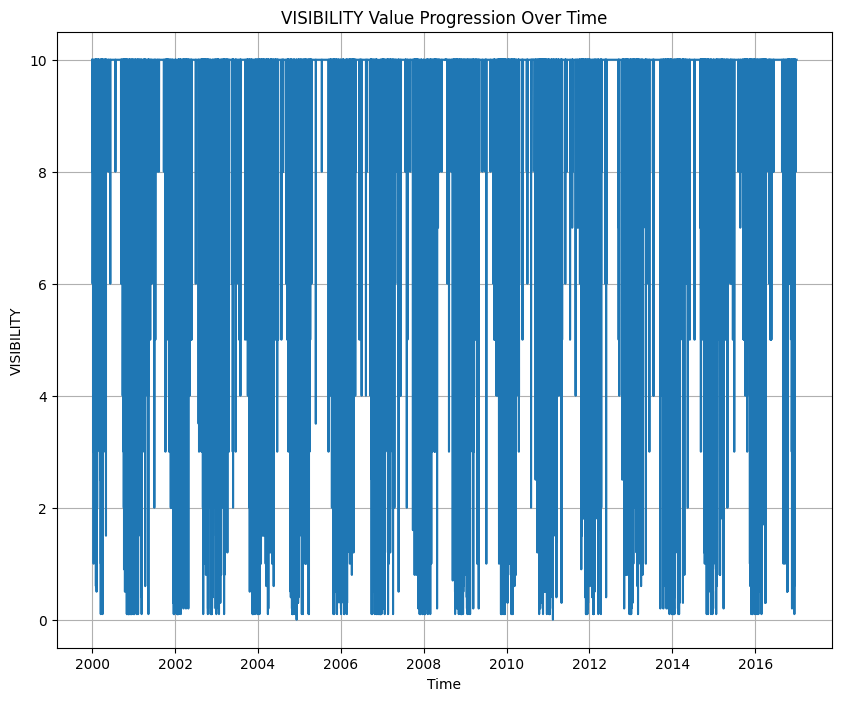

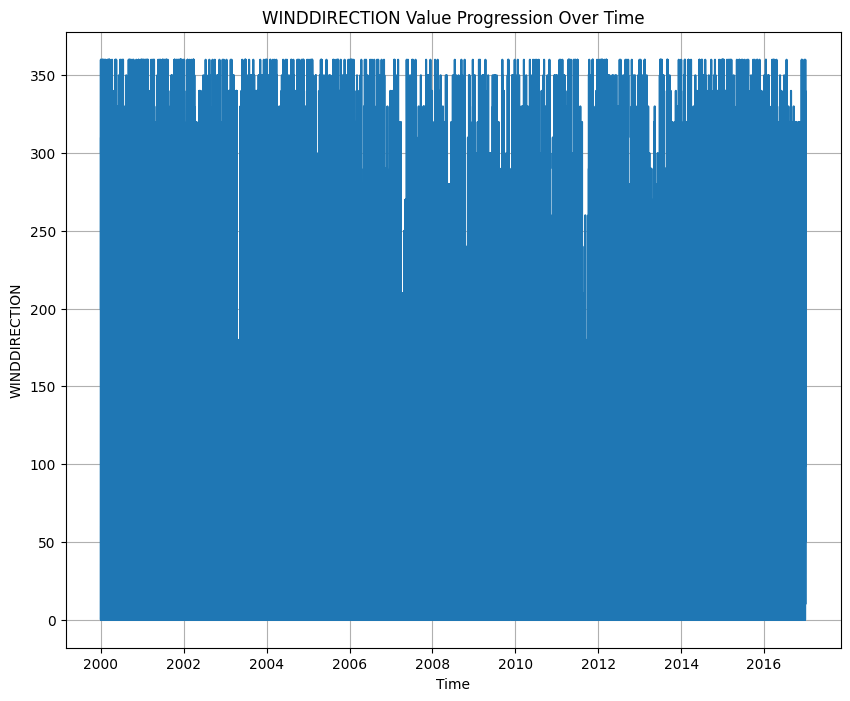

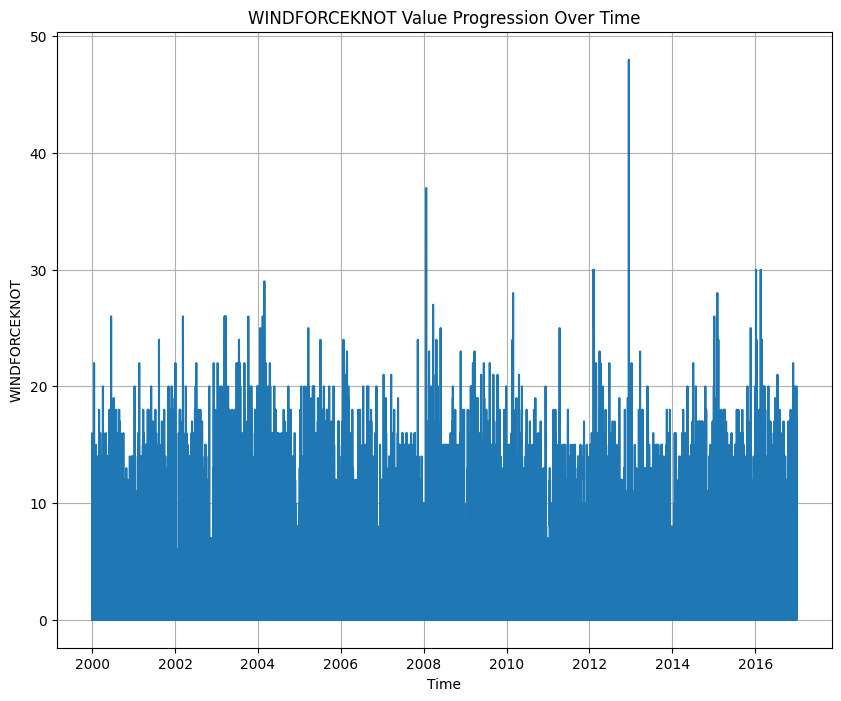

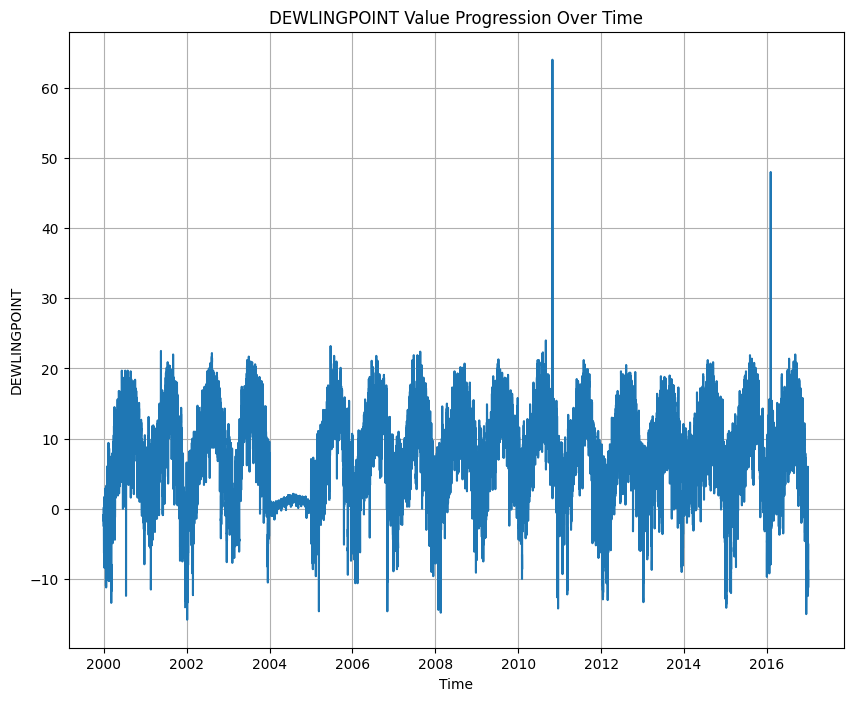

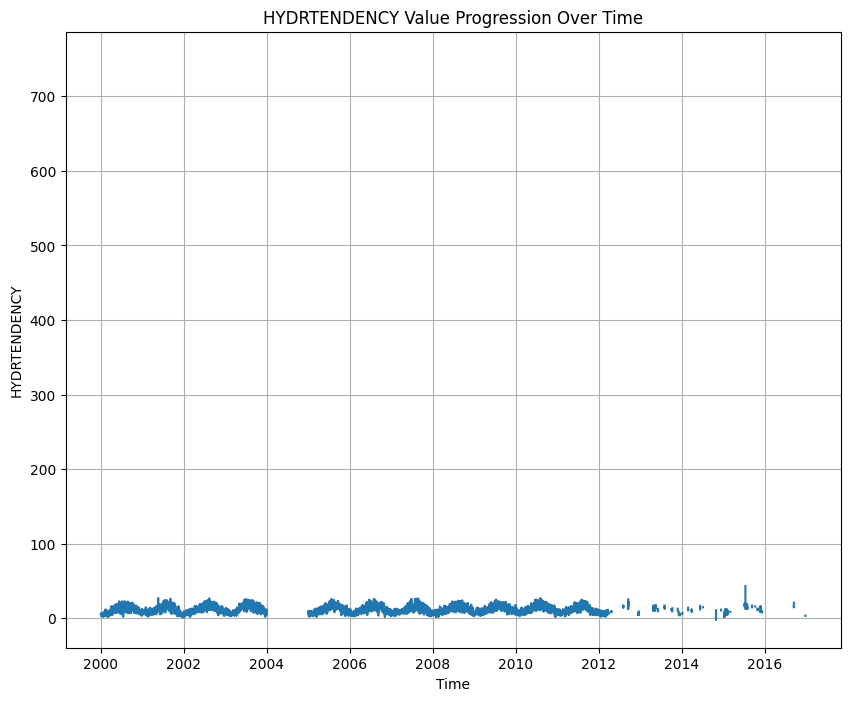

In [ ]:

temp = pd.DataFrame({
    'timestamp': pd.to_datetime(train[['OBSERVATIONYEAR', 'OBSERVATIONMONTH', 'OBSERVATIONDAY', 'OBSERVATIONHOUR']].rename(
        columns={
            'OBSERVATIONYEAR': 'year',
            'OBSERVATIONMONTH': 'month',
            'OBSERVATIONDAY': 'day',
            'OBSERVATIONHOUR': 'hour'
        }
    ) )
})


for col in target_cols:

    plt.figure(figsize=(10, 8))
    plt.plot(temp['timestamp'], train[col] )
    plt.title(f"{col} Value Progression Over Time")
    plt.xlabel("Time")
    plt.ylabel(col)
    plt.grid(True)
    plt.show()

## Preproccessing step

### Utils

In [ ]:
def create_time_features(df, min ,mask_flag):
   hour = df["OBSERVATIONHOUR"].astype(np.int64)
   if mask_flag:
      return pd.DataFrame({
        "year" : df["OBSERVATIONYEAR"]-min,
        "month": df["OBSERVATIONMONTH"].astype(np.int64),
        "day": df["OBSERVATIONDAY"].astype(np.int64),
        "weekday": pd.to_datetime(
            dict(year=df["OBSERVATIONYEAR"],
                  month=df["OBSERVATIONMONTH"],
                  day=df["OBSERVATIONDAY"])
        ).dt.weekday,
        "hour": hour,


        "is_event_time": ((hour == 2) | (hour == 6)).astype(np.int64),


        "hour_sin": np.sin(2 * np.pi * hour / 24),
        "hour_cos": np.cos(2 * np.pi * hour / 24),
        })
   else:
     return pd.DataFrame({
        "year" : df["OBSERVATIONYEAR"]-min,
        "month": df["OBSERVATIONMONTH"].astype(np.int64),
        "day": df["OBSERVATIONDAY"].astype(np.int64),
        "weekday": pd.to_datetime(
            dict(year=df["OBSERVATIONYEAR"],
                  month=df["OBSERVATIONMONTH"],
                  day=df["OBSERVATIONDAY"])
        ).dt.weekday,
        "hour": hour
      })


def create_sequences_with_marks(X, y, stamp, seq_len, label_len, pred_len, test_flag):
    X_seq, y_seq, X_mark, y_mark = [], [], [], []
    indices = []

    total_len = seq_len + label_len + pred_len

    for i in range(len(X) - total_len + 1):
        s_begin = i
        s_end = i + seq_len

        r_begin = s_end - label_len
        r_end = s_end + pred_len

        X_seq.append(X[s_begin:s_end])
        y_seq.append(y[r_begin:r_end])

        X_mark.append(stamp[s_begin:s_end])
        y_mark.append(stamp[r_begin:r_end])


        indices.append(r_end - pred_len)



    if test_flag:
      return (
          np.array(X_seq),
          np.array(y_seq),
          np.array(X_mark),
          np.array(y_mark),
          np.array(indices)
      )
    else:
      return (
          np.array(X_seq),
          np.array(y_seq),
          np.array(X_mark),
          np.array(y_mark)
      )





def fit_transform_per_label(train_df, val_df, test_df, cols):
  scalers = {}

  train_scaled = train_df.copy()
  val_scaled   = val_df.copy()
  test_scaled  = test_df.copy()

  for col in cols:
    scaler = StandardScaler()

    train_scaled[[col]] = scaler.fit_transform(train_df[[col]])
    val_scaled[[col]]   = scaler.transform(val_df[[col]])
    test_scaled[[col]]  = scaler.transform(test_df[[col]])

    scalers[col] = scaler

  return train_scaled, val_scaled, test_scaled, scalers


def inverse_transform_per_label(arr, scalers, target_cols):
  original_shape = arr.shape
  arr_2d = arr.reshape(-1, arr.shape[-1])
  inversed = np.zeros_like(arr_2d)

  for i, col in enumerate(target_cols):
      inversed[:, i] = scalers[col].inverse_transform(
          arr_2d[:, [i]]
      ).ravel()

  return inversed.reshape(original_shape)

### Function from preprocessing

In [ ]:
def preprocess_data(train, val, test, min_year, mask_flag, target_cols,
                     seq_len, label_len, pred_len, batch_size):

    interpolation_cols = [
        "DRYTEMP", "RELHUMIDITY",
        "WETTEMP", "VISIBILITY",
        "WINDFORCEKNOT", "DEWLINGPOINT",
    ]

    train = train.copy()
    val   = val.copy()
    test  = test.copy()

    train[interpolation_cols] = train[interpolation_cols].interpolate(method="linear").ffill().bfill()
    val[interpolation_cols]   = val[interpolation_cols].interpolate(method="linear").ffill().bfill()
    test[interpolation_cols]  = test[interpolation_cols].interpolate(method="linear").ffill().bfill()






    temp = pd.DataFrame({
    'timestamp': pd.to_datetime(train[['OBSERVATIONYEAR', 'OBSERVATIONMONTH', 'OBSERVATIONDAY', 'OBSERVATIONHOUR']].rename(
        columns={
            'OBSERVATIONYEAR': 'year',
            'OBSERVATIONMONTH': 'month',
            'OBSERVATIONDAY': 'day',
            'OBSERVATIONHOUR': 'hour'
            }
        ) )
    })

    plt.figure(figsize=(10, 8))
    plt.plot(temp["timestamp"], train["WETTEMP"])
    plt.title("WETTEMP Value Progression Over Time after linear interpolation")
    plt.xlabel("Time")
    plt.ylabel("WETTEMP")
    plt.grid(True)
    plt.show()

    train = train.fillna(0)
    val   = val.fillna(0)
    test  = test.fillna(0)

    train_mark = create_time_features(train, min_year, mask_flag)
    val_mark   = create_time_features(val, min_year, mask_flag)
    test_mark  = create_time_features(test, min_year, mask_flag)

    max_year = test_mark["year"].max()

    X_train = train[target_cols].copy()
    X_val   = val[target_cols].copy()
    X_test  = test[target_cols].copy()

    y_train = X_train.copy()
    y_val   = X_val.copy()
    y_test  = X_test.copy()

    # Per-label scaling
    X_train_scaled, X_val_scaled, X_test_scaled, x_scalers = fit_transform_per_label(
        X_train, X_val, X_test, target_cols
    )

    y_train_scaled, y_val_scaled, y_test_scaled, y_scalers = fit_transform_per_label(
        y_train, y_val, y_test, target_cols
    )

    X_train_scaled = X_train_scaled.values.astype(float)
    X_val_scaled   = X_val_scaled.values.astype(float)
    X_test_scaled  = X_test_scaled.values.astype(float)

    y_train_scaled = y_train_scaled.values.astype(float)
    y_val_scaled   = y_val_scaled.values.astype(float)
    y_test_scaled  = y_test_scaled.values.astype(float)

    X_train_mark = train_mark.values.astype(int)
    X_val_mark   = val_mark.values.astype(int)
    X_test_mark  = test_mark.values.astype(int)

    X_train_mark[:, 1] -= 1
    X_train_mark[:, 2] -= 1
    X_val_mark[:, 1] -= 1
    X_val_mark[:, 2] -= 1
    X_test_mark[:, 1] -= 1
    X_test_mark[:, 2] -= 1

    X_train_seq, y_train_seq, X_train_mark_seq, y_train_mark_seq = create_sequences_with_marks(
        X_train_scaled, y_train_scaled, X_train_mark,
        seq_len=seq_len, label_len=label_len, pred_len=pred_len,
        test_flag=False
    )

    X_val_seq, y_val_seq, X_val_mark_seq, y_val_mark_seq = create_sequences_with_marks(
        X_val_scaled, y_val_scaled, X_val_mark,
        seq_len=seq_len, label_len=label_len, pred_len=pred_len,
        test_flag=False
    )

    X_test_seq, y_test_seq, X_test_mark_seq, y_test_mark_seq, test_indices = create_sequences_with_marks(
        X_test_scaled, y_test_scaled, X_test_mark,
        seq_len=seq_len, label_len=label_len, pred_len=pred_len,
        test_flag=True
    )

    train_dataset = TensorDataset(
        torch.tensor(X_train_seq, dtype=torch.float32),
        torch.tensor(y_train_seq, dtype=torch.float32),
        torch.tensor(X_train_mark_seq, dtype=torch.long),
        torch.tensor(y_train_mark_seq, dtype=torch.long)
    )

    val_dataset = TensorDataset(
        torch.tensor(X_val_seq, dtype=torch.float32),
        torch.tensor(y_val_seq, dtype=torch.float32),
        torch.tensor(X_val_mark_seq, dtype=torch.long),
        torch.tensor(y_val_mark_seq, dtype=torch.long)
    )

    test_dataset = TensorDataset(
        torch.tensor(X_test_seq, dtype=torch.float32),
        torch.tensor(y_test_seq, dtype=torch.float32),
        torch.tensor(X_test_mark_seq, dtype=torch.long),
        torch.tensor(y_test_mark_seq, dtype=torch.long)
    )

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader, max_year, test_indices, x_scalers, y_scalers

### Preprocessing set up

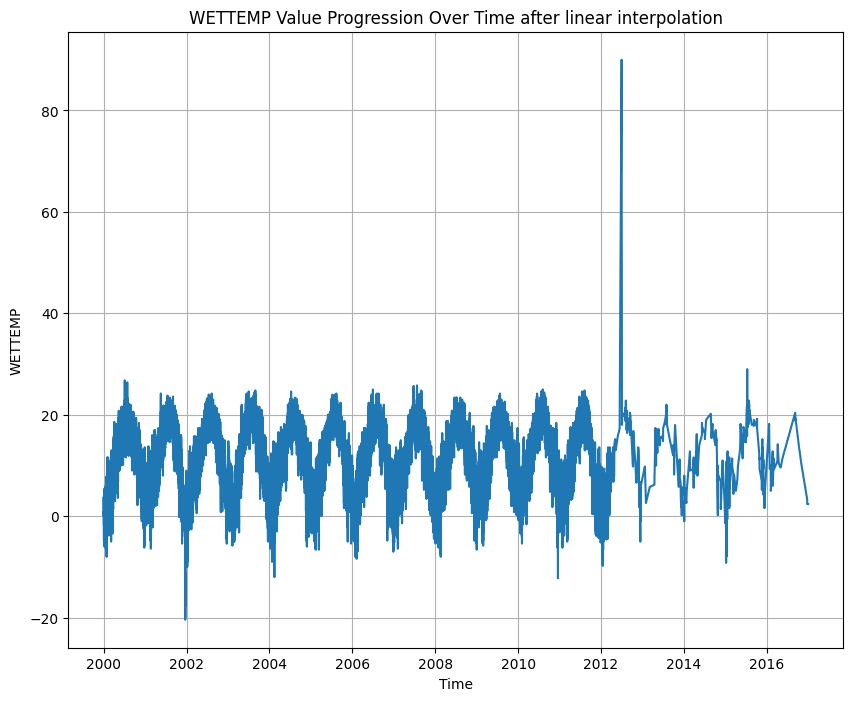

In [ ]:
original_time_test = test[[
    "OBSERVATIONYEAR",
    "OBSERVATIONMONTH",
    "OBSERVATIONDAY",
    "OBSERVATIONHOUR"
]].reset_index(drop=True)

# optional if you have IDs
if "WMONO" in test.columns:
    original_id_test = test["WMONO"].reset_index(drop=True)
else:
    original_id_test = None






mask_flag=False
seq_len = 168
pred_len = 56
label_len = 56
batch_size = 32


train_loader, val_loader, test_loader, max_year, test_indices, x_scalers, y_scalers = preprocess_data(train,
                                                                                val,
                                                                                test,
                                                                                min_year,
                                                                                mask_flag,
                                                                                target_cols,
                                                                                seq_len,
                                                                                label_len,
                                                                                pred_len,
                                                                                batch_size)


## Autoformer


### Utils

In [ ]:
def adjust_learning_rate(optimizer, epoch, learning_rate, lradj):
    # lr = args.learning_rate * (0.2 ** (epoch // 2))
    if lradj == 'type1':
        lr_adjust = {epoch: learning_rate * (0.5 ** ((epoch - 1) // 1))}
    elif lradj == 'type2':
        lr_adjust = {
            2: 5e-5, 4: 1e-5, 6: 5e-6, 8: 1e-6,
            10: 5e-7, 15: 1e-7, 20: 5e-8
        }
    if epoch in lr_adjust.keys():
        lr = lr_adjust[epoch]
        for param_group in optimizer.param_groups:
            param_group['lr'] = lr
        print('Updating learning rate to {}'.format(lr))
    return lr

class EarlyStopping:
    def __init__(self, patience=7, verbose=False, delta=0):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.inf
        self.delta = delta

    def __call__(self, val_loss, model):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score

        elif score < self.best_score + self.delta:
            self.counter += 1
            print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score

            self.counter = 0


def calculate_masked_loss(outputs, batch_y, batch_y_mark, pred_len):
    pred = outputs
    true = batch_y
    sparse_idx = [1, 2]
    # mask
    mask = batch_y_mark[:, -pred_len:, 4]
    mask = mask.float().to(pred.device)

    # split indices
    all_idx = list(range(pred.shape[-1]))
    dense_idx = [i for i in all_idx if i not in sparse_idx]

    pred_dense = pred[..., dense_idx]
    true_dense = true[..., dense_idx]

    pred_sparse = pred[..., sparse_idx]
    true_sparse = true[..., sparse_idx]

    # losses
    loss_dense = ((pred_dense - true_dense) ** 2).mean()

    mask_exp = mask.unsqueeze(-1)
    loss_sparse = ((pred_sparse - true_sparse) ** 2) * mask_exp
    loss_sparse = loss_sparse.sum() / (mask.sum() * len(sparse_idx) + 1e-6)
    alpha = mask.numel() / (mask.sum() + 1e-6)
    loss = loss_dense + loss_sparse
    return loss



class dotdict(dict):
    """dot.notation access to dictionary attributes"""
    __getattr__ = dict.get
    __setattr__ = dict.__setitem__
    __delattr__ = dict.__delitem__


class StandardScaler():
    def __init__(self, mean, std):
        self.mean = mean
        self.std = std

    def transform(self, data):
        return (data - self.mean) / self.std

    def inverse_transform(self, data):
        return (data * self.std) + self.mean





### Time Features

In [ ]:
class TimeFeature:
    def __init__(self):
        pass

    def __call__(self, index: pd.DatetimeIndex) -> np.ndarray:
        pass

    def __repr__(self):
        return self.__class__.__name__ + "()"


class SecondOfMinute(TimeFeature):
    """Minute of hour encoded as value between [-0.5, 0.5]"""

    def __call__(self, index: pd.DatetimeIndex) -> np.ndarray:
        return index.second / 59.0 - 0.5


class MinuteOfHour(TimeFeature):
    """Minute of hour encoded as value between [-0.5, 0.5]"""

    def __call__(self, index: pd.DatetimeIndex) -> np.ndarray:
        return index.minute / 59.0 - 0.5


class HourOfDay(TimeFeature):
    """Hour of day encoded as value between [-0.5, 0.5]"""

    def __call__(self, index: pd.DatetimeIndex) -> np.ndarray:
        return index.hour / 23.0 - 0.5


class DayOfWeek(TimeFeature):
    """Hour of day encoded as value between [-0.5, 0.5]"""

    def __call__(self, index: pd.DatetimeIndex) -> np.ndarray:
        return index.dayofweek / 6.0 - 0.5


class DayOfMonth(TimeFeature):
    """Day of month encoded as value between [-0.5, 0.5]"""

    def __call__(self, index: pd.DatetimeIndex) -> np.ndarray:
        return (index.day - 1) / 30.0 - 0.5


class DayOfYear(TimeFeature):
    """Day of year encoded as value between [-0.5, 0.5]"""

    def __call__(self, index: pd.DatetimeIndex) -> np.ndarray:
        return (index.dayofyear - 1) / 365.0 - 0.5


class MonthOfYear(TimeFeature):
    """Month of year encoded as value between [-0.5, 0.5]"""

    def __call__(self, index: pd.DatetimeIndex) -> np.ndarray:
        return (index.month - 1) / 11.0 - 0.5


class WeekOfYear(TimeFeature):
    """Week of year encoded as value between [-0.5, 0.5]"""

    def __call__(self, index: pd.DatetimeIndex) -> np.ndarray:
        return (index.isocalendar().week - 1) / 52.0 - 0.5


def time_features_from_frequency_str(freq_str: str) -> List[TimeFeature]:
    """
    Returns a list of time features that will be appropriate for the given frequency string.
    Parameters
    ----------
    freq_str
        Frequency string of the form [multiple][granularity] such as "12H", "5min", "1D" etc.
    """

    features_by_offsets = {
        offsets.YearEnd: [],
        offsets.QuarterEnd: [MonthOfYear],
        offsets.MonthEnd: [MonthOfYear],
        offsets.Week: [DayOfMonth, WeekOfYear],
        offsets.Day: [DayOfWeek, DayOfMonth, DayOfYear],
        offsets.BusinessDay: [DayOfWeek, DayOfMonth, DayOfYear],
        offsets.Hour: [HourOfDay, DayOfWeek, DayOfMonth, DayOfYear],
        offsets.Minute: [
            MinuteOfHour,
            HourOfDay,
            DayOfWeek,
            DayOfMonth,
            DayOfYear,
        ],
        offsets.Second: [
            SecondOfMinute,
            MinuteOfHour,
            HourOfDay,
            DayOfWeek,
            DayOfMonth,
            DayOfYear,
        ],
    }

    offset = to_offset(freq_str)

    for offset_type, feature_classes in features_by_offsets.items():
        if isinstance(offset, offset_type):
            return [cls() for cls in feature_classes]

    supported_freq_msg = f"""
    Unsupported frequency {freq_str}
    The following frequencies are supported:
        Y   - yearly
            alias: A
        M   - monthly
        W   - weekly
        D   - daily
        B   - business days
        H   - hourly
        T   - minutely
            alias: min
        S   - secondly
    """
    raise RuntimeError(supported_freq_msg)


def time_features(dates, freq='h'):
    return np.vstack([feat(dates) for feat in time_features_from_frequency_str(freq)])

### Embedings

In [ ]:
def compared_version(ver1, ver2):
    """
    :param ver1
    :param ver2
    :return: ver1< = >ver2 False/True
    """
    list1 = str(ver1).split(".")
    list2 = str(ver2).split(".")

    for i in range(len(list1)) if len(list1) < len(list2) else range(len(list2)):
        if int(list1[i]) == int(list2[i]):
            pass
        elif int(list1[i]) < int(list2[i]):
            return -1
        else:
            return 1

    if len(list1) == len(list2):
        return True
    elif len(list1) < len(list2):
        return False
    else:
        return True

class PositionalEmbedding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEmbedding, self).__init__()
        # Compute the positional encodings once in log space.
        pe = torch.zeros(max_len, d_model).float()
        pe.require_grad = False

        position = torch.arange(0, max_len).float().unsqueeze(1)
        div_term = (torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model)).exp()

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return self.pe[:, :x.size(1)]


class TokenEmbedding(nn.Module):
    def __init__(self, c_in, d_model):
        super(TokenEmbedding, self).__init__()
        padding = 1 if compared_version(torch.__version__, '1.5.0') else 2
        self.tokenConv = nn.Conv1d(in_channels=c_in, out_channels=d_model,
                                   kernel_size=3, padding=padding, padding_mode='circular', bias=False)
        for m in self.modules():
            if isinstance(m, nn.Conv1d):
                nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='leaky_relu')

    def forward(self, x):
        x = self.tokenConv(x.permute(0, 2, 1)).transpose(1, 2)
        return x


class FixedEmbedding(nn.Module):
    def __init__(self, c_in, d_model):
        super(FixedEmbedding, self).__init__()

        w = torch.zeros(c_in, d_model).float()
        w.require_grad = False

        position = torch.arange(0, c_in).float().unsqueeze(1)
        div_term = (torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model)).exp()

        w[:, 0::2] = torch.sin(position * div_term)
        w[:, 1::2] = torch.cos(position * div_term)

        self.emb = nn.Embedding(c_in, d_model)
        self.emb.weight = nn.Parameter(w, requires_grad=False)

    def forward(self, x):
        return self.emb(x).detach()


class TemporalEmbedding(nn.Module):
    def __init__(self, d_model, max_year, embed_type='fixed', freq='h'):
        super(TemporalEmbedding, self).__init__()

        minute_size = 4
        hour_size = 8
        weekday_size = 7
        day_size = 32
        month_size = 12
        year_size=max_year+1

        Embed = FixedEmbedding if embed_type == 'fixed' else nn.Embedding
        if freq == 't':
            self.minute_embed = Embed(minute_size, d_model)
        self.year_embed = Embed(year_size, d_model)
        self.hour_embed = Embed(hour_size, d_model)
        self.weekday_embed = Embed(weekday_size, d_model)
        self.day_embed = Embed(day_size, d_model)
        self.month_embed = Embed(month_size, d_model)

    def forward(self, x):
        x = x.long()
        minute_x = self.minute_embed(x[:, :, 5]) if hasattr(self, 'minute_embed') else 0.
        hour_x = self.hour_embed(x[:, :, 4])
        weekday_x = self.weekday_embed(x[:, :, 3])
        day_x = self.day_embed(x[:, :, 2])
        month_x = self.month_embed(x[:, :, 1])
        year_x = self.year_embed(x[:, :, 0])

        return hour_x + weekday_x + day_x + month_x + year_x + minute_x





class DataEmbedding(nn.Module):
    def __init__(self, c_in, d_model, embed_type='fixed', freq='h', dropout=0.1):
        super(DataEmbedding, self).__init__()

        self.value_embedding = TokenEmbedding(c_in=c_in, d_model=d_model)
        self.position_embedding = PositionalEmbedding(d_model=d_model)
        self.temporal_embedding = TemporalEmbedding(d_model=d_model, embed_type=embed_type, freq=freq)
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, x, x_mark):
        x = self.value_embedding(x) + self.temporal_embedding(x_mark) + self.position_embedding(x)
        return self.dropout(x)


class DataEmbedding_wo_pos(nn.Module):
    def __init__(self, c_in, d_model, max_year, embed_type='fixed', freq='h', dropout=0.1):
        super(DataEmbedding_wo_pos, self).__init__()

        self.value_embedding = TokenEmbedding(c_in=c_in, d_model=d_model)
        self.position_embedding = PositionalEmbedding(d_model=d_model)
        self.temporal_embedding = TemporalEmbedding(d_model=d_model, max_year=max_year, embed_type=embed_type, freq=freq)
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, x, x_mark):
        x = self.value_embedding(x) + self.temporal_embedding(x_mark)
        return self.dropout(x)

### Encoder-Decoder Layers

In [ ]:
class my_Layernorm(nn.Module):
    """
    Special designed layernorm for the seasonal part
    """
    def __init__(self, channels):
        super(my_Layernorm, self).__init__()
        self.layernorm = nn.LayerNorm(channels)

    def forward(self, x):
        x_hat = self.layernorm(x)
        bias = torch.mean(x_hat, dim=1).unsqueeze(1).repeat(1, x.shape[1], 1)
        return x_hat - bias


class moving_avg(nn.Module):
    """
    Moving average block to highlight the trend of time series
    """
    def __init__(self, kernel_size, stride):
        super(moving_avg, self).__init__()
        self.kernel_size = kernel_size
        self.avg = nn.AvgPool1d(kernel_size=kernel_size, stride=stride, padding=0)

    def forward(self, x):
        # padding on the both ends of time series
        front = x[:, 0:1, :].repeat(1, (self.kernel_size - 1) // 2, 1)
        end = x[:, -1:, :].repeat(1, (self.kernel_size - 1) // 2, 1)
        x = torch.cat([front, x, end], dim=1)
        x = self.avg(x.permute(0, 2, 1))
        x = x.permute(0, 2, 1)
        return x


class series_decomp(nn.Module):
    """
    Series decomposition block
    """
    def __init__(self, kernel_size):
        super(series_decomp, self).__init__()
        self.moving_avg = moving_avg(kernel_size, stride=1)

    def forward(self, x):
        moving_mean = self.moving_avg(x)
        res = x - moving_mean
        return res, moving_mean


class EncoderLayer(nn.Module):
    """
    Autoformer encoder layer with the progressive decomposition architecture
    """
    def __init__(self, attention, d_model, d_ff=None, moving_avg=25, dropout=0.1, activation="relu"):
        super(EncoderLayer, self).__init__()
        d_ff = d_ff or 4 * d_model
        self.attention = attention
        self.conv1 = nn.Conv1d(in_channels=d_model, out_channels=d_ff, kernel_size=1, bias=False)
        self.conv2 = nn.Conv1d(in_channels=d_ff, out_channels=d_model, kernel_size=1, bias=False)
        self.decomp1 = series_decomp(moving_avg)
        self.decomp2 = series_decomp(moving_avg)
        self.dropout = nn.Dropout(dropout)
        self.activation = F.relu if activation == "relu" else F.gelu

    def forward(self, x, attn_mask=None):
        new_x, attn = self.attention(
            x, x, x,
            attn_mask=attn_mask
        )
        x = x + self.dropout(new_x)
        x, _ = self.decomp1(x)
        y = x
        y = self.dropout(self.activation(self.conv1(y.transpose(-1, 1))))
        y = self.dropout(self.conv2(y).transpose(-1, 1))
        res, _ = self.decomp2(x + y)
        return res, attn


class Encoder(nn.Module):
    """
    Autoformer encoder
    """
    def __init__(self, attn_layers, conv_layers=None, norm_layer=None):
        super(Encoder, self).__init__()
        self.attn_layers = nn.ModuleList(attn_layers)
        self.conv_layers = nn.ModuleList(conv_layers) if conv_layers is not None else None
        self.norm = norm_layer

    def forward(self, x, attn_mask=None):
        attns = []
        if self.conv_layers is not None:
            for attn_layer, conv_layer in zip(self.attn_layers, self.conv_layers):
                x, attn = attn_layer(x, attn_mask=attn_mask)
                x = conv_layer(x)
                attns.append(attn)
            x, attn = self.attn_layers[-1](x)
            attns.append(attn)
        else:
            for attn_layer in self.attn_layers:
                x, attn = attn_layer(x, attn_mask=attn_mask)
                attns.append(attn)

        if self.norm is not None:
            x = self.norm(x)

        return x, attns


class DecoderLayer(nn.Module):
    """
    Autoformer decoder layer with the progressive decomposition architecture
    """
    def __init__(self, self_attention, cross_attention, d_model, c_out, d_ff=None,
                 moving_avg=25, dropout=0.1, activation="relu"):
        super(DecoderLayer, self).__init__()
        d_ff = d_ff or 4 * d_model
        self.self_attention = self_attention
        self.cross_attention = cross_attention
        self.conv1 = nn.Conv1d(in_channels=d_model, out_channels=d_ff, kernel_size=1, bias=False)
        self.conv2 = nn.Conv1d(in_channels=d_ff, out_channels=d_model, kernel_size=1, bias=False)
        self.decomp1 = series_decomp(moving_avg)
        self.decomp2 = series_decomp(moving_avg)
        self.decomp3 = series_decomp(moving_avg)
        self.dropout = nn.Dropout(dropout)
        self.projection = nn.Conv1d(in_channels=d_model,out_channels=c_out, kernel_size=3, padding=1, stride=1, padding_mode='circular', bias=False)
        self.activation = F.relu if activation == "relu" else F.gelu

    def forward(self, x, cross, x_mask=None, cross_mask=None):
        x = x + self.dropout(self.self_attention(
            x, x, x,
            attn_mask=x_mask
        )[0])
        x, trend1 = self.decomp1(x)
        x = x + self.dropout(self.cross_attention(
            x, cross, cross,
            attn_mask=cross_mask
        )[0])
        x, trend2 = self.decomp2(x)
        y = x
        y = self.dropout(self.activation(self.conv1(y.transpose(-1, 1))))
        y = self.dropout(self.conv2(y).transpose(-1, 1))
        x, trend3 = self.decomp3(x + y)

        residual_trend = trend1 + trend2 + trend3
        residual_trend = self.projection(residual_trend.permute(0, 2, 1)).transpose(1, 2)
        return x, residual_trend


class Decoder(nn.Module):
    """
    Autoformer encoder
    """
    def __init__(self, layers, norm_layer=None, projection=None):
        super(Decoder, self).__init__()
        self.layers = nn.ModuleList(layers)
        self.norm = norm_layer
        self.projection = projection

    def forward(self, x, cross, x_mask=None, cross_mask=None, trend=None):
        for layer in self.layers:
            x, residual_trend = layer(x, cross, x_mask=x_mask, cross_mask=cross_mask)
            trend = trend + residual_trend

        if self.norm is not None:
            x = self.norm(x)

        if self.projection is not None:
            x = self.projection(x)
        return x, trend

### Auto-Correlation

In [ ]:
class AutoCorrelation(nn.Module):
    """
    AutoCorrelation Mechanism with the following two phases:
    (1) period-based dependencies discovery
    (2) time delay aggregation
    This block can replace the self-attention family mechanism seamlessly.
    """
    def __init__(self, mask_flag=True, factor=1, scale=None, attention_dropout=0.1, output_attention=False):
        super(AutoCorrelation, self).__init__()
        self.factor = factor
        self.scale = scale
        self.mask_flag = mask_flag
        self.output_attention = output_attention
        self.dropout = nn.Dropout(attention_dropout)

    def time_delay_agg_training(self, values, corr):
        """
        SpeedUp version of Autocorrelation (a batch-normalization style design)
        This is for the training phase.
        """
        head = values.shape[1]
        channel = values.shape[2]
        length = values.shape[3]
        # find top k
        top_k = int(self.factor * math.log(length))
        mean_value = torch.mean(torch.mean(corr, dim=1), dim=1)
        index = torch.topk(torch.mean(mean_value, dim=0), top_k, dim=-1)[1]
        weights = torch.stack([mean_value[:, index[i]] for i in range(top_k)], dim=-1)
        # update corr
        tmp_corr = torch.softmax(weights, dim=-1)
        # aggregation
        tmp_values = values
        delays_agg = torch.zeros_like(values).float()
        for i in range(top_k):
            pattern = torch.roll(tmp_values, -int(index[i]), -1)
            delays_agg = delays_agg + pattern * \
                         (tmp_corr[:, i].unsqueeze(1).unsqueeze(1).unsqueeze(1).repeat(1, head, channel, length))
        return delays_agg

    def time_delay_agg_inference(self, values, corr):
        """
        SpeedUp version of Autocorrelation (a batch-normalization style design)
        This is for the inference phase.
        """
        batch = values.shape[0]
        head = values.shape[1]
        channel = values.shape[2]
        length = values.shape[3]
        # index init
        init_index = torch.arange(length).unsqueeze(0).unsqueeze(0).unsqueeze(0)\
            .repeat(batch, head, channel, 1).to(values.device)
        # find top k
        top_k = int(self.factor * math.log(length))
        mean_value = torch.mean(torch.mean(corr, dim=1), dim=1)
        weights, delay = torch.topk(mean_value, top_k, dim=-1)
        # update corr
        tmp_corr = torch.softmax(weights, dim=-1)
        # aggregation
        tmp_values = values.repeat(1, 1, 1, 2)
        delays_agg = torch.zeros_like(values).float()
        for i in range(top_k):
            tmp_delay = init_index + delay[:, i].unsqueeze(1).unsqueeze(1).unsqueeze(1).repeat(1, head, channel, length)
            pattern = torch.gather(tmp_values, dim=-1, index=tmp_delay)
            delays_agg = delays_agg + pattern * \
                         (tmp_corr[:, i].unsqueeze(1).unsqueeze(1).unsqueeze(1).repeat(1, head, channel, length))
        return delays_agg

    def time_delay_agg_full(self, values, corr):
        """
        Standard version of Autocorrelation
        """
        batch = values.shape[0]
        head = values.shape[1]
        channel = values.shape[2]
        length = values.shape[3]
        # index init
        init_index = torch.arange(length).unsqueeze(0).unsqueeze(0).unsqueeze(0)\
            .repeat(batch, head, channel, 1).to(values.device)
        # find top k
        top_k = int(self.factor * math.log(length))
        weights, delay = torch.topk(corr, top_k, dim=-1)
        # update corr
        tmp_corr = torch.softmax(weights, dim=-1)
        # aggregation
        tmp_values = values.repeat(1, 1, 1, 2)
        delays_agg = torch.zeros_like(values).float()
        for i in range(top_k):
            tmp_delay = init_index + delay[..., i].unsqueeze(-1)
            pattern = torch.gather(tmp_values, dim=-1, index=tmp_delay)
            delays_agg = delays_agg + pattern * (tmp_corr[..., i].unsqueeze(-1))
        return delays_agg

    def forward(self, queries, keys, values, attn_mask):
        B, L, H, E = queries.shape
        _, S, _, D = values.shape
        if L > S:
            zeros = torch.zeros_like(queries[:, :(L - S), :]).float()
            values = torch.cat([values, zeros], dim=1)
            keys = torch.cat([keys, zeros], dim=1)
        else:
            values = values[:, :L, :, :]
            keys = keys[:, :L, :, :]

        # period-based dependencies
        q_fft = torch.fft.rfft(queries.permute(0, 2, 3, 1).contiguous(), dim=-1)
        k_fft = torch.fft.rfft(keys.permute(0, 2, 3, 1).contiguous(), dim=-1)
        res = q_fft * torch.conj(k_fft)
        corr = torch.fft.irfft(res, n=L, dim=-1)

        # time delay agg
        if self.training:
            V = self.time_delay_agg_training(values.permute(0, 2, 3, 1).contiguous(), corr).permute(0, 3, 1, 2)
        else:
            V = self.time_delay_agg_inference(values.permute(0, 2, 3, 1).contiguous(), corr).permute(0, 3, 1, 2)

        if self.output_attention:
            return (V.contiguous(), corr.permute(0, 3, 1, 2))
        else:
            return (V.contiguous(), None)


class AutoCorrelationLayer(nn.Module):
    def __init__(self, correlation, d_model, n_heads, d_keys=None,
                 d_values=None):
        super(AutoCorrelationLayer, self).__init__()

        d_keys = d_keys or (d_model // n_heads)
        d_values = d_values or (d_model // n_heads)

        self.inner_correlation = correlation
        self.query_projection = nn.Linear(d_model, d_keys * n_heads)
        self.key_projection = nn.Linear(d_model, d_keys * n_heads)
        self.value_projection = nn.Linear(d_model, d_values * n_heads)
        self.out_projection = nn.Linear(d_values * n_heads, d_model)
        self.n_heads = n_heads

    def forward(self, queries, keys, values, attn_mask):
        B, L, _ = queries.shape
        _, S, _ = keys.shape
        H = self.n_heads

        queries = self.query_projection(queries).view(B, L, H, -1)
        keys = self.key_projection(keys).view(B, S, H, -1)
        values = self.value_projection(values).view(B, S, H, -1)

        out, attn = self.inner_correlation(
            queries,
            keys,
            values,
            attn_mask
        )
        out = out.view(B, L, -1)

        return self.out_projection(out), attn

### Predict And Valuation Functions

In [ ]:
def predict_test(
    model,
    test_loader,
    y_scalers,
    original_time_test,
    test_indices,
    target_cols,
    device,
    pred_len,
    label_len,
    save_path="test_predictions.csv",
    original_id_test=None
):

    model.eval()

    all_preds = []
    all_trues = []

    with torch.no_grad():

        for batch_x, batch_y, batch_x_mark, batch_y_mark in test_loader:

            batch_x = batch_x.float().to(device)
            batch_y = batch_y.float().to(device)

            batch_x_mark = batch_x_mark.float().to(device)
            batch_y_mark = batch_y_mark.float().to(device)

            outputs, batch_y = _predict(
                model,
                batch_x,
                batch_y,
                batch_x_mark,
                batch_y_mark,
                pred_len,
                label_len,
                output_attention=False,
                device=device
            )

            all_preds.append(outputs.cpu().numpy())
            all_trues.append(batch_y.cpu().numpy())

    preds = np.concatenate(all_preds, axis=0)
    trues = np.concatenate(all_trues, axis=0)

    # Inverse transform predictions
    preds_reshaped = preds.reshape(-1, preds.shape[-1])
    preds_inverse = inverse_transform_per_label(preds_reshaped, y_scalers, target_cols)
    preds_inverse = preds_inverse.reshape(preds.shape)

    # Inverse transform true values
    trues_reshaped = trues.reshape(-1, trues.shape[-1])
    trues_inverse = inverse_transform_per_label(trues_reshaped, y_scalers, target_cols)
    trues_inverse = trues_inverse.reshape(trues.shape)


    final_preds = preds_inverse
    final_trues = trues_inverse

    final_preds_2d= preds_inverse[:, -1, :]

    # Metrics
    mse = mean_squared_error(
        final_trues.reshape(-1),
        final_preds.reshape(-1)
    )

    mae = mean_absolute_error(
        final_trues.reshape(-1),
        final_preds.reshape(-1)
    )

    print(f"Test MSE: {mse:.7f}")
    print(f"Test MAE: {mae:.7f}")

    # Build dataframe
    aligned_time = original_time_test.iloc[test_indices].reset_index(drop=True)

    pred_df = pd.DataFrame(final_preds_2d, columns=target_cols)

    final_df = pd.concat([aligned_time, pred_df], axis=1)

    if original_id_test is not None:
        aligned_id = original_id_test.iloc[test_indices].reset_index(drop=True)
        final_df.insert(0, "WMONO", aligned_id)

    final_df.to_csv(save_path, index=False)

    print(f"Predictions saved to: {save_path}")

    return final_df

In [ ]:
def _predict(model, batch_x, batch_y, batch_x_mark, batch_y_mark, pred_len, label_len, output_attention, device):
        # decoder input
        dec_inp = torch.zeros_like(batch_y[:, -pred_len:, :]).float()
        dec_inp = torch.cat([batch_y[:, :label_len, :], dec_inp], dim=1).float().to(device)
        # encoder - decoder

        def _run_model():
            outputs = model(batch_x, batch_x_mark, dec_inp, batch_y_mark)
            if isinstance(outputs, tuple):
                outputs = outputs[0]

            return outputs


        outputs = _run_model()

        f_dim =  0
        outputs = outputs[:, -pred_len:, f_dim:]
        batch_y = batch_y[:, -pred_len:, f_dim:].to(device)

        return outputs, batch_y

In [ ]:
def vali(model, vali_loader, criterion, pred_len, label_len,
         output_attention, device, mask_flag):

    total_loss = []
    total_mae = []

    model.eval()

    with torch.no_grad():
        for i, (batch_x, batch_y, batch_x_mark, batch_y_mark) in enumerate(vali_loader):

            batch_x = batch_x.float().to(device)
            batch_y = batch_y.float().to(device)

            batch_x_mark = batch_x_mark.float().to(device)
            batch_y_mark = batch_y_mark.float().to(device)

            outputs, batch_y = _predict(
                model,
                batch_x,
                batch_y,
                batch_x_mark,
                batch_y_mark,
                pred_len,
                label_len,
                output_attention,
                device
            )

            # MSE loss
            if mask_flag:
                loss = calculate_masked_loss(
                    outputs,
                    batch_y,
                    batch_y_mark,
                    pred_len
                )

                # masked MAE
                mask = batch_y_mark[:, -pred_len:, :].to(device)
                mae = torch.sum(torch.abs(outputs - batch_y) * mask) / (mask.sum() + 1e-8)

            else:
                loss = criterion(outputs, batch_y)

                # regular MAE
                mae = torch.mean(torch.abs(outputs - batch_y))

            total_loss.append(loss.item())
            total_mae.append(mae.item())

    avg_loss = np.average(total_loss)
    avg_mae = np.average(total_mae)

    model.train()

    return avg_loss, avg_mae

### Training Function

In [ ]:
def train_model(model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    num_epochs,
    patience,
    pred_len,
    label_len,
    learning_rate,
    output_attention=True,
    mask_flag=False):



        best_val_loss = float('inf')
        best_model_state = None
        time_now = time.time()

        train_steps = len(train_loader)
        early_stopping = EarlyStopping(patience=patience, verbose=True)

        scaler = torch.amp.GradScaler()

        for epoch in range(num_epochs):
            iter_count = 0
            train_loss = []

            model.train()
            epoch_time = time.time()
            for i, (batch_x, batch_y, batch_x_mark, batch_y_mark) in enumerate(train_loader):

                iter_count += 1
                optimizer.zero_grad()
                batch_x = batch_x.float().to(device)
                batch_y = batch_y.float().to(device)
                batch_x_mark = batch_x_mark.float().to(device)
                batch_y_mark = batch_y_mark.float().to(device)





                outputs, batch_y = _predict(model, batch_x, batch_y, batch_x_mark, batch_y_mark, pred_len, label_len, output_attention, device)


                if mask_flag:
                   loss = calculate_masked_loss(outputs, batch_y, batch_y_mark, pred_len)
                else:
                    loss = criterion(outputs, batch_y)

                train_loss.append(loss.item())

                if (i + 1) % 100 == 0:
                    #print("\titers: {0}, epoch: {1} | loss: {2:.7f}".format(i + 1, epoch , loss.item()))
                    speed = (time.time() - time_now) / iter_count
                    left_time = speed * ((num_epochs - epoch) * train_steps - i)
                    #print('\tspeed: {:.4f}s/iter; left time: {:.4f}s'.format(speed, left_time))
                    iter_count = 0
                    time_now = time.time()

                if scaler :
                    scaler.scale(loss).backward()
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    optimizer.step()

            print("Epoch: {} cost time: {}".format(epoch , time.time() - epoch_time))
            train_loss = np.average(train_loss)


            vali_loss, mae = vali(model, val_loader,  criterion,  pred_len, label_len, output_attention, device, mask_flag)


            print("Epoch: {0}, Steps: {1} | Train Loss: {2:.7f} Vali Loss: {3:.7f} MAE Loss: {4:.7f}".format(
                epoch , train_steps, train_loss, vali_loss, mae))
            early_stopping(vali_loss, model)
            if early_stopping.early_stop:
                print("Early stopping")
                break

            learing_rate=adjust_learning_rate(optimizer, epoch + 1, learning_rate, 'type1')

            if vali_loss < best_val_loss:
                best_val_loss = vali_loss
                best_model_state = model.state_dict()

        if best_model_state is not None:
            model.load_state_dict(best_model_state)
            print(f"\nBest model restored with Vali Loss: {best_val_loss:.7f}")




        return model

### Model

In [ ]:
class Autoformer(nn.Module):
  def __init__(
        self,
        enc_in,
        dec_in,
        c_out,
        dropout,
        seq_len,
        label_len,
        pred_len,
        freq,
        max_year,
        d_model=32,
        n_heads=8,
        e_layers=2,
        d_layers=1,
        d_ff=64,
        moving_avg=5,
        factor=1,
        activation="gelu",
        output_attention=True,
        latent_dim=16,
        latent_hidden=64
    ):
        super().__init__()


        self.enc_in = enc_in
        self.dec_in = dec_in
        self.c_out = c_out
        self.dropout = dropout
        self.seq_len = seq_len
        self.label_len = label_len
        self.pred_len = pred_len
        self.d_model = d_model
        self.n_heads = n_heads
        self.e_layers = e_layers
        self.d_layers = d_layers
        self.d_ff = d_ff
        self.moving_avg = moving_avg
        self.freq = freq
        self.factor = factor
        self.activation = activation
        self.output_attention = output_attention
        self.max_year = max_year
        kernel_size = moving_avg

        self.decomp = series_decomp(kernel_size)

        self.enc_embedding=DataEmbedding_wo_pos(c_in=self.enc_in, d_model=self.d_model, max_year=self.max_year, freq=self.freq, dropout=self.dropout)
        self.dec_embedding=DataEmbedding_wo_pos(c_in=self.dec_in, d_model=self.d_model, max_year=self.max_year, freq=self.freq, dropout=self.dropout)


        self.encoder = Encoder(
            [
                EncoderLayer(
                    AutoCorrelationLayer(
                        AutoCorrelation(False, factor, attention_dropout=dropout,
                                        output_attention=output_attention),
                        d_model, n_heads),
                    d_model,
                    d_ff,
                    moving_avg=moving_avg,
                    dropout=dropout,
                    activation=activation
                ) for l in range(e_layers)
            ],
            norm_layer=my_Layernorm(d_model)
        )
        # Decoder
        self.decoder = Decoder(
            [
                DecoderLayer(
                    AutoCorrelationLayer(
                        AutoCorrelation(True, factor, attention_dropout=dropout,
                                        output_attention=False),
                        d_model, n_heads),
                    AutoCorrelationLayer(
                        AutoCorrelation(False, factor, attention_dropout=dropout,
                                        output_attention=False),
                        d_model, n_heads),
                    d_model,
                    c_out,
                    d_ff,
                    moving_avg=moving_avg,
                    dropout=dropout,
                    activation=activation,
                )
                for l in range(d_layers)
            ],
            norm_layer=my_Layernorm(d_model),
            projection=nn.Linear(d_model, c_out, bias=True)
        )



  def forward(self, x_enc, x_mark_enc, x_dec, x_mark_dec,
                enc_self_mask=None, dec_self_mask=None, dec_enc_mask=None):
        # decomp init
        mean = torch.mean(x_enc, dim=1).unsqueeze(1).repeat(1, self.pred_len, 1)
        zeros = torch.zeros([x_dec.shape[0], self.pred_len, x_dec.shape[2]], device=x_enc.device)
        seasonal_init, trend_init = self.decomp(x_enc)
        # decoder input
        trend_init = torch.cat([trend_init[:, -self.label_len:, :], mean], dim=1)
        seasonal_init = torch.cat([seasonal_init[:, -self.label_len:, :], zeros], dim=1)
        # enc
        enc_out = self.enc_embedding(x_enc, x_mark_enc)
        enc_out, attns = self.encoder(enc_out, attn_mask=enc_self_mask)
        # dec
        dec_out = self.dec_embedding(seasonal_init, x_mark_dec)
        seasonal_part, trend_part = self.decoder(dec_out, enc_out, x_mask=dec_self_mask, cross_mask=dec_enc_mask,
                                                 trend=trend_init)
        # final
        dec_out = trend_part + seasonal_part

        if self.output_attention:
            return dec_out[:, -self.pred_len:, :], attns
        else:
            return dec_out[:, -self.pred_len:, :]  # [B, L, D]


### Initialization and training  

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# Model Hyper Parameters
num_features = len(target_cols)
c_out = len(target_cols)

model_dim = 256
num_heads = 8
num_layers_e = 2
num_layers_d = 1
d_ff = 512
dropout = 0
mean_rolling = 7
freq="h"
lr=1e-3

num_epochs=10

model = Autoformer(
    enc_in=num_features,
    dec_in=num_features,
    c_out=c_out,
    d_model=model_dim,
    d_ff=d_ff,
    freq=freq,
    seq_len=seq_len,
    label_len=label_len,
    pred_len=pred_len,
    n_heads=num_heads,
    moving_avg=mean_rolling,
    max_year=max_year,
    e_layers=num_layers_e,
    d_layers=num_layers_d,
    dropout=dropout,

)

model = model.to(device)


criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)


trained_model = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=num_epochs,
    patience=7,
    learning_rate=lr,
    device=device,
    pred_len=pred_len,
    label_len=label_len,
    output_attention=False,
    mask_flag=mask_flag,
    use_amp=False
)




Using device: cuda
Epoch: 0 cost time: 84.97790884971619
Epoch: 0, Steps: 1540 | Train Loss: 0.5243388 Vali Loss: 0.4151348 MAE Loss: 0.3791627
Updating learning rate to 0.001
Epoch: 1 cost time: 86.18734908103943
Epoch: 1, Steps: 1540 | Train Loss: 0.4715513 Vali Loss: 0.4076043 MAE Loss: 0.3701629
Updating learning rate to 0.0005
Epoch: 2 cost time: 87.77198243141174
Epoch: 2, Steps: 1540 | Train Loss: 0.4073592 Vali Loss: 0.4343849 MAE Loss: 0.3880410
EarlyStopping counter: 1 out of 7
Updating learning rate to 0.00025
Epoch: 3 cost time: 87.66907215118408
Epoch: 3, Steps: 1540 | Train Loss: 0.3205669 Vali Loss: 0.4643239 MAE Loss: 0.4142170
EarlyStopping counter: 2 out of 7
Updating learning rate to 0.000125
Epoch: 4 cost time: 87.70489549636841
Epoch: 4, Steps: 1540 | Train Loss: 0.2517334 Vali Loss: 0.4775499 MAE Loss: 0.4212506
EarlyStopping counter: 3 out of 7
Updating learning rate to 6.25e-05
Epoch: 5 cost time: 87.69124102592468
Epoch: 5, Steps: 1540 | Train Loss: 0.2188729 V

### Testing Phase

In [ ]:
def plot_test_vs_predictions(
    test,
    predictions,
    target_cols,
    save_dir=None,
    pred_len=24,
    show=True
):
    # Keep only the part of test that matches prediction length
    test_plot = test.iloc[-len(predictions):].reset_index(drop=True)
    predictions_plot = predictions.reset_index(drop=True)

    temp = pd.DataFrame({
        "timestamp": pd.to_datetime(
            test_plot[[
                "OBSERVATIONYEAR",
                "OBSERVATIONMONTH",
                "OBSERVATIONDAY",
                "OBSERVATIONHOUR"
            ]].rename(columns={
                "OBSERVATIONYEAR": "year",
                "OBSERVATIONMONTH": "month",
                "OBSERVATIONDAY": "day",
                "OBSERVATIONHOUR": "hour"
            })
        )
    })

    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)

    for col in target_cols:
        plt.figure(figsize=(10, 8))

        plt.plot(
            temp["timestamp"],
            test_plot[col].values,
            label=f"True {col}"
        )

        plt.plot(
            temp["timestamp"],
            predictions_plot[col].values,
            label=f"Predicted {col}",
            alpha=0.5
        )

        plt.title(f"{col}: Test vs Prediction")
        plt.xlabel("Time")
        plt.ylabel(col)
        plt.grid(True)
        plt.legend()

        if save_dir is not None:
            plt.savefig(
                os.path.join(save_dir, f"{col}_test_vs_prediction{pred_len}.png"),
                dpi=300,
                bbox_inches="tight"
            )

        if show:
            plt.show()
        else:
            plt.close()

Test MSE: 942.2486572
Test MAE: 9.8487654
Predictions saved to: /content/drive/MyDrive/E.M.Y_project/test_predictions_auto_168-56.csv


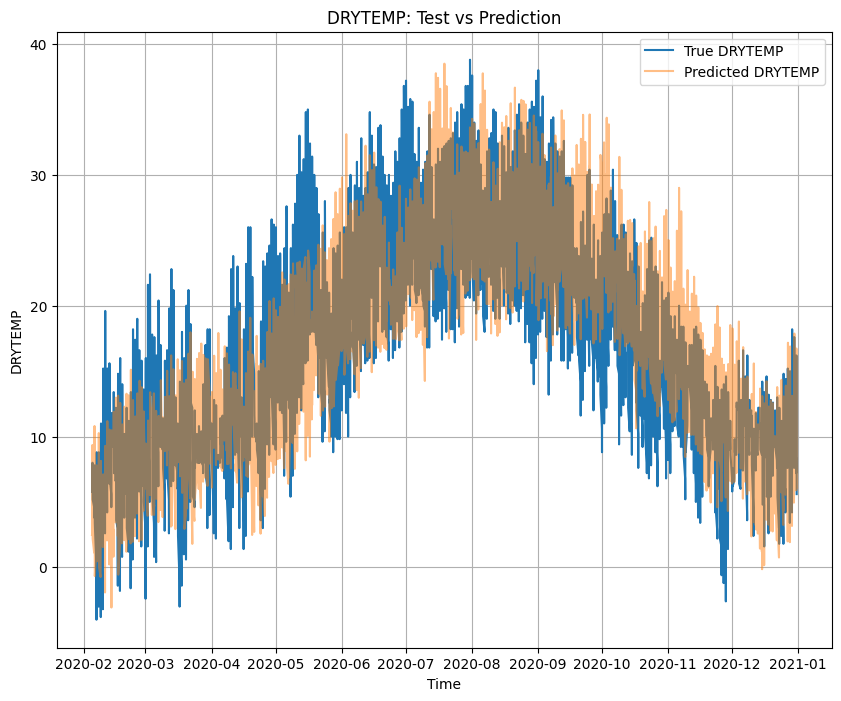

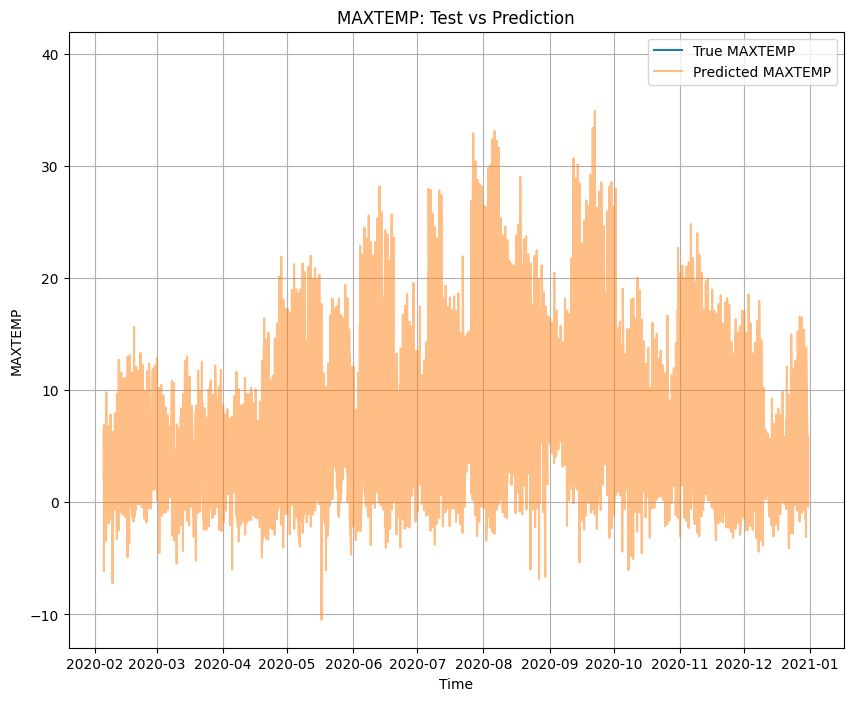

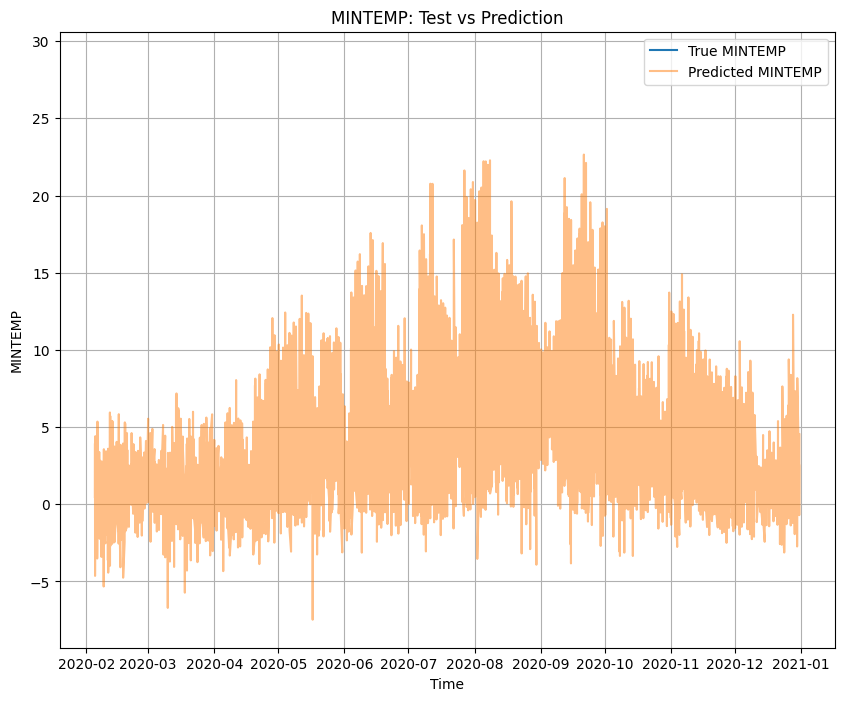

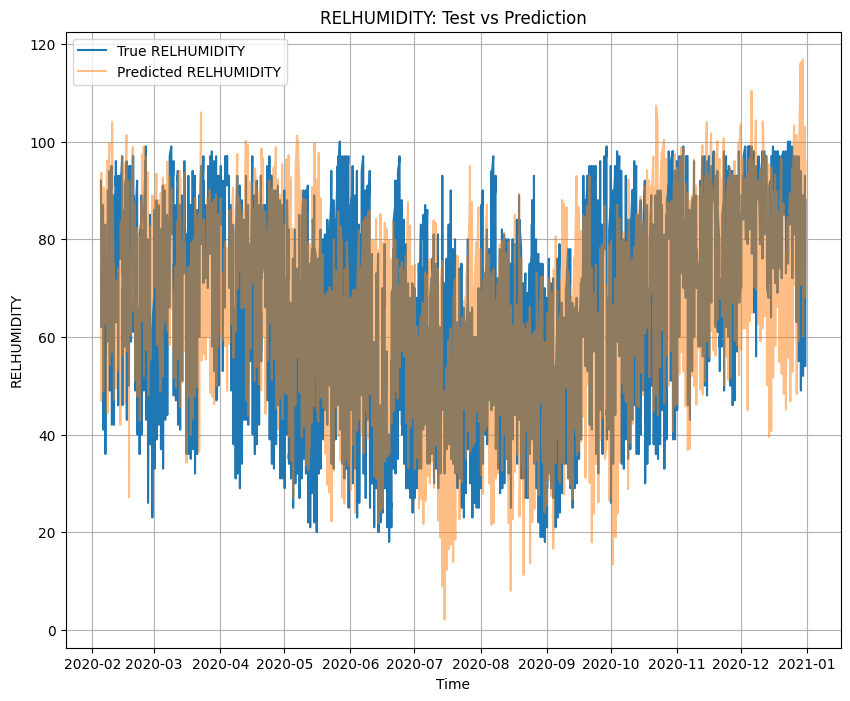

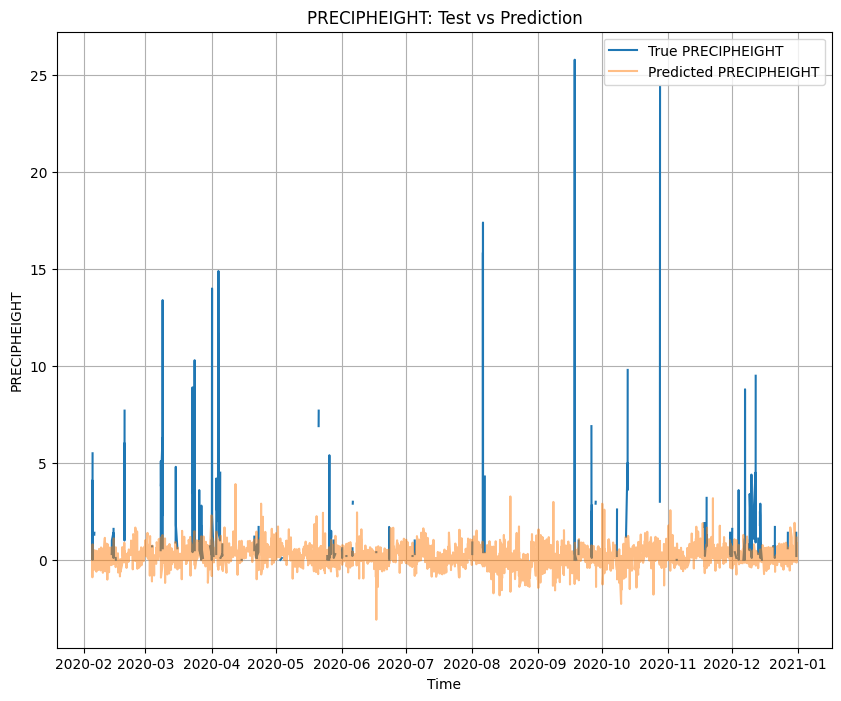

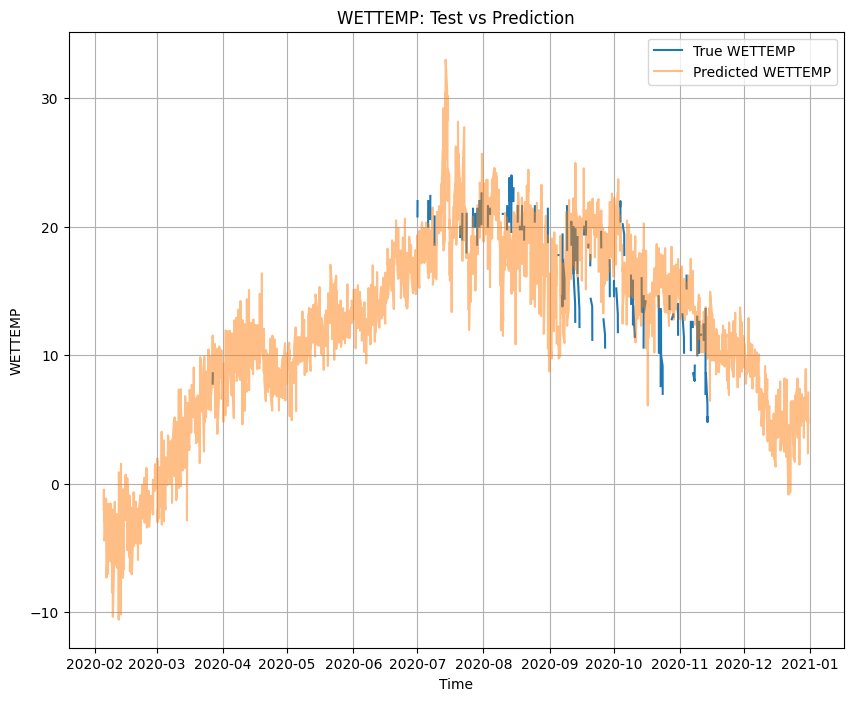

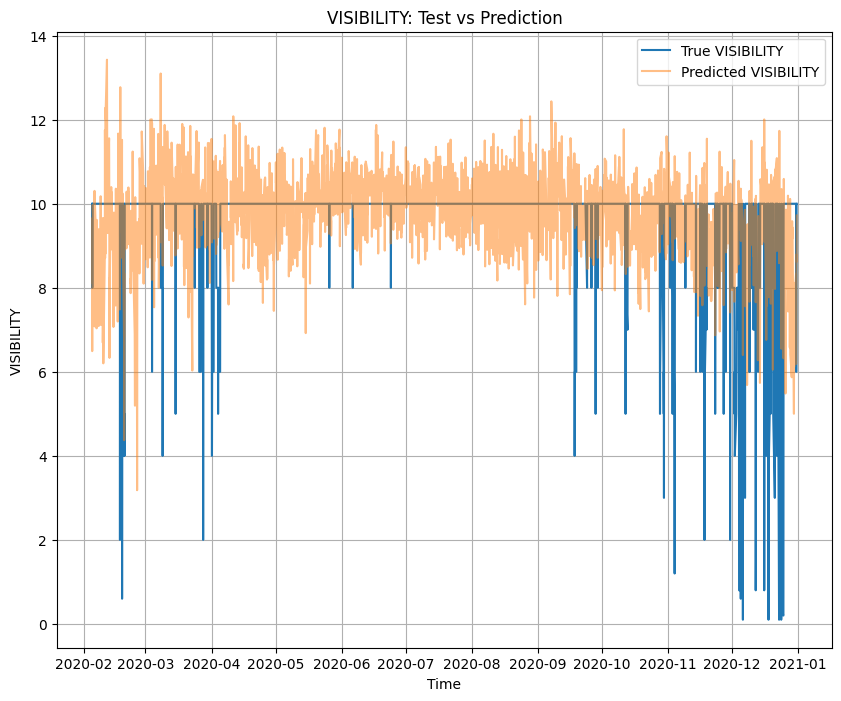

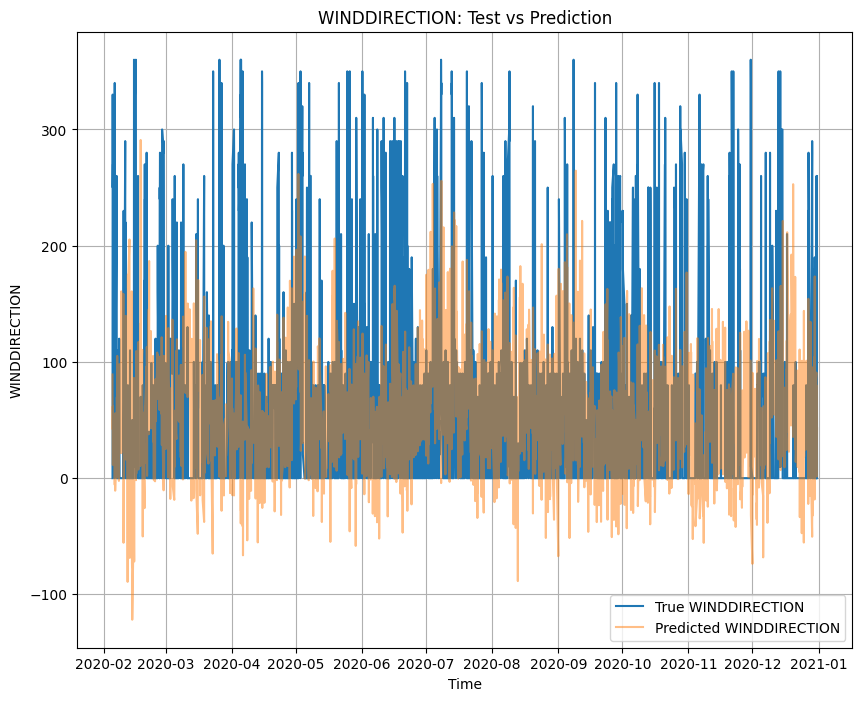

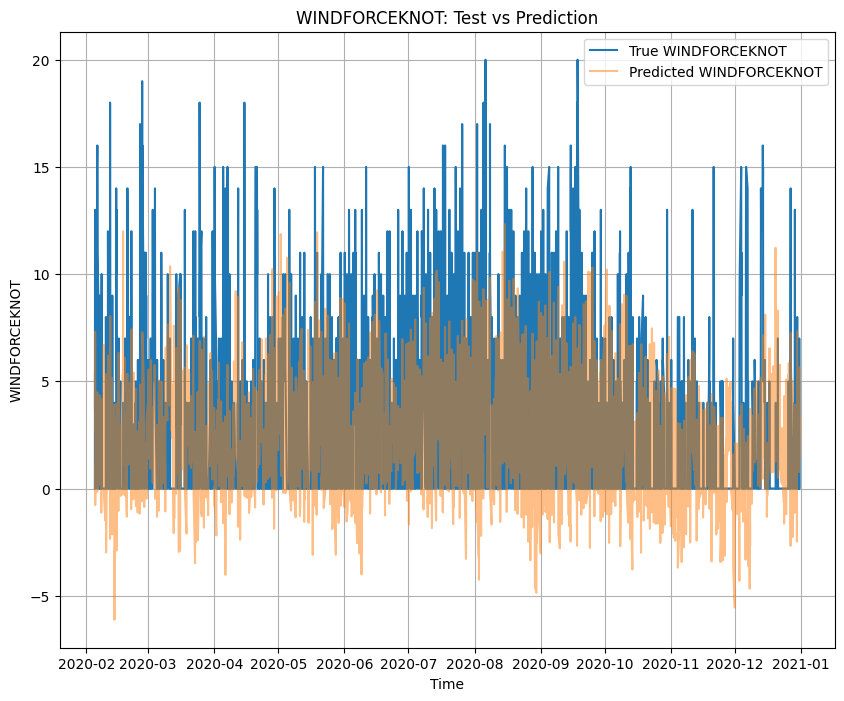

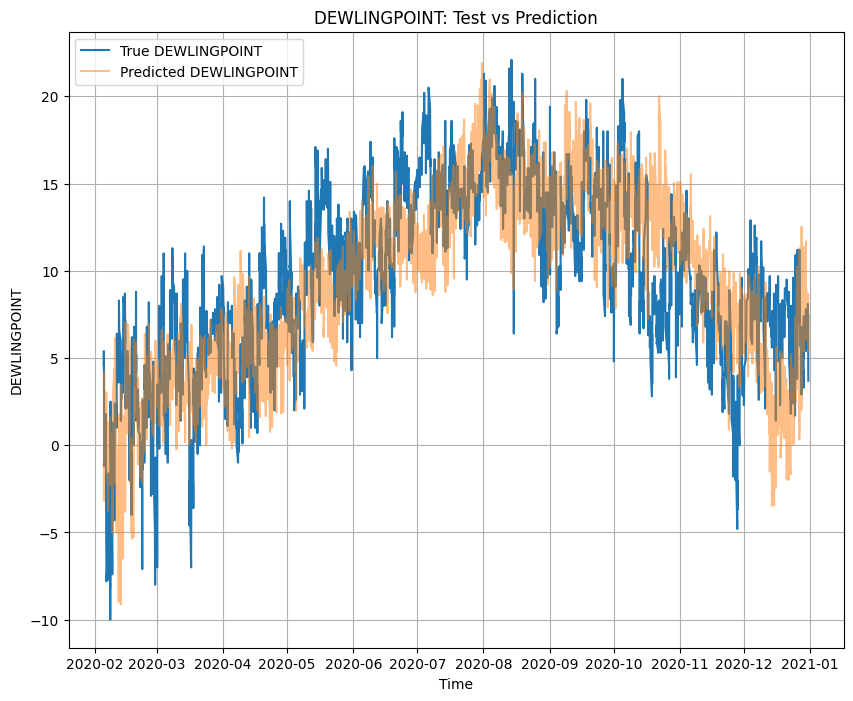

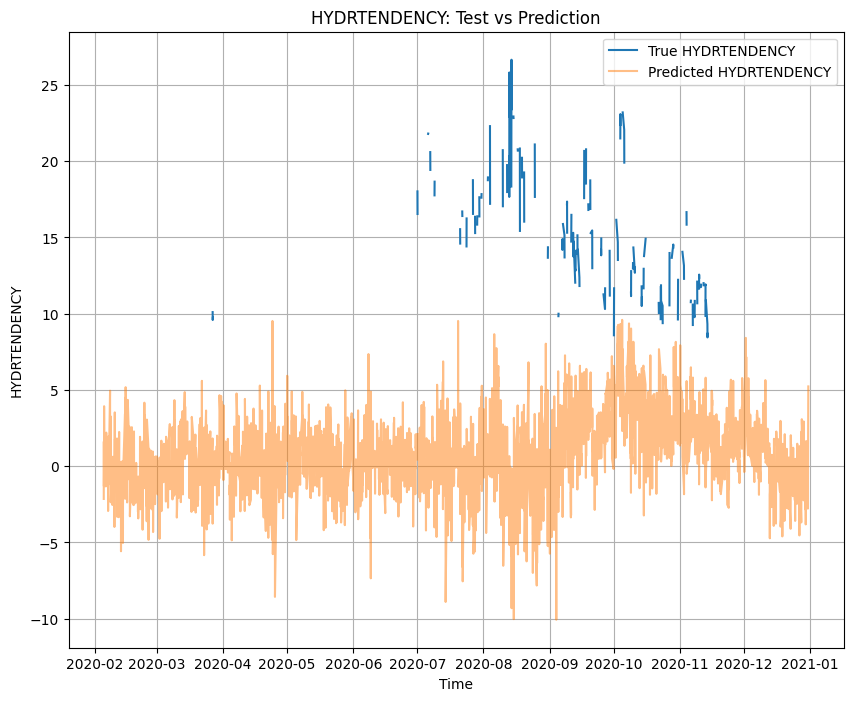

In [ ]:

save_path="/content/drive/MyDrive/E.M.Y_project/test_predictions_auto_168-56.csv"

predict_df = predict_test(
    model=trained_model,
    test_loader=test_loader,
    y_scalers=y_scalers,
    original_time_test=original_time_test,
    test_indices=test_indices,
    target_cols=target_cols,
    device=device,
    pred_len=pred_len,
    label_len=label_len,
    save_path=save_path,
    original_id_test=original_id_test
)



plot_test_vs_predictions(
    test=test,
    predictions=predict_df,
    target_cols=target_cols,
    pred_len=pred_len,
    save_dir="/content/drive/MyDrive/E.M.Y_project/test_vs_predicted/autoformer"
)


